# Challenge : Recommandation d'Emploi Basée sur le Comportement avec Apprentissage Machine en Ligne et Filtrage Collaboratif par HrFlow.ai

Lien GitHub vers le repo du projet qui contient l'ensemble des données, le notebook et les sorties. 

https://github.com/caglanaz/Behavioral-Job-Recommendation-with-Online-Machine-Learning-and-Collaborative-Filtering.git

## 0. Pré-requis d'exécution

### Installation rapide des packages requis
`pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm`

### Remarque
Les seeds sont fixées dans le notebook (pour les modèles) pour améliorer la reproductibilité des résultats.

## 1. Problématique du challenge

Ce challenge porte sur la **détection de recommandations d’emplois** à partir de l’historique de navigation de candidats sur un jobboard. Concrètement, lorsqu’un candidat navigue sur la plateforme, il consulte successivement plusieurs offres d’emploi et effectue des actions sur celles-ci : soit il se contente de les **consulter** (*view*), soit il décide de **postuler** (*apply*). Ce parcours séquentiel constitue une **session de navigation**.

L’objectif du challenge est double :

1. **Prédire les 10 emplois** que le candidat est le plus susceptible d’explorer après sa session courante. Cette tâche est évaluée par le **MRR (Mean Reciprocal Rank)**, une métrique de ranking qui mesure à quel rang le bon emploi apparaît dans notre liste de recommandations.
2. **Prédire l’action du candidat** sur le prochain emploi : va-t-il simplement le *consulter* ou bien *postuler* ? Cette tâche est un problème de **classification binaire**, évalué par l’**Accuracy**.

Le **score final** du challenge combine ces deux métriques de la manière suivante :

$$
\text{Score} = 0.7 \times \text{MRR} + 0.3 \times \text{Accuracy}
$$

La composante MRR (70 %) a un poids prédominant, ce qui reflète l’importance de la qualité des recommandations dans un contexte réel de jobboard.

## Approche adoptée

Pour répondre à cette problématique, nous avons adopté une démarche structurée en plusieurs étapes, conformément aux bonnes pratiques du Machine Learning :

1. **Exploration des données** : Comprendre la structure du jeu de données, les distributions et les caractéristiques des sessions de navigation.
2. **Feature Engineering** : Construire des variables explicatives pertinentes à partir de l’historique de navigation (longueur de session, ratio d’applications, popularité des emplois, tendance comportementale, etc.).
3. **Modèle de référence** : Établir une baseline avec une régression logistique, un modèle simple et interprétable.
4. **Modèle non supervisé** : Appliquer un clustering KMeans pour identifier des profils de candidats et enrichir nos features.
5. **Modèles supervisés optimisés** : Entraîner et optimiser par GridSearchCV plusieurs modèles (Random Forest, XGBoost, SVM, arbre de décision) pour la classification de l’action.
6. **Interprétation** : Utiliser SHAP pour comprendre quelles variables influencent le plus les prédictions.
7. **Deep Learning** : Tester un réseau de neurones dense (MLP) en tant qu’approche complémentaire.
8. **Système de recommandation** : Implémenter un filtrage collaboratif User-User et une chaîne de Markov pour la partie recommandation (MRR).
9. **Comparaison finale** : Comparer toutes les approches et sélectionner la meilleure combinaison pour la soumission.

## 2. Imports et Configuration

Avant toute chose, nous importons l’ensemble des bibliothèques nécessaires à notre analyse. Celles-ci couvrent la manipulation de données (pandas, numpy), la visualisation (matplotlib, seaborn), les algorithmes de Machine Learning classiques (scikit-learn, XGBoost, LightGBM), l’interprétation des modèles (SHAP), ainsi que le Deep Learning (PyTorch).

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# --- Data ---
import pandas as pd
import numpy as np
import ast
from collections import Counter, defaultdict

# --- Visualisation ---
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# --- ML ---
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, f1_score, roc_curve)
import xgboost as xgb
import lightgbm as lgb

# --- Interpretation ---
import shap

# --- Deep Learning ---
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# --- Utilitaires ---
from tqdm import tqdm
from scipy.spatial.distance import cosine

print("Tous les imports ont été chargés.")

Tous les imports ont été charges avec succès.


## 3. Chargement et Exploration des Données

### Description du jeu de données

Le jeu de données est composé de trois fichiers :
- **x_train** et **x_test** : Chaque ligne représente une **session de navigation** identifiée par un `session_id`. Pour chaque session, on dispose de la séquence ordonnée des `job_ids` consultés et de la séquence correspondante des `actions` effectuées (*view* ou *apply*).
- **y_train** : Pour chaque session du train, on connaît le **job cible** (le prochain emploi que le candidat va consulter) et l’**action** qu’il va effectuer dessus.

L’objectif est donc de prédire, pour les sessions du test, à la fois le prochain emploi (parmi un top-10 de recommandations) et l’action associée.

Nous commençons par charger ces données et examiner leur structure, puis nous analysons les distributions des variables pour détecter d’éventuels déséquilibres de classes ou patterns particuliers.

In [ ]:
# --- Chargement des donnees ---
def parse_pylist(s):
    """Parse une chaine représentant une liste Python"""
    return ast.literal_eval(s) if isinstance(s, str) else s

x_train = pd.read_csv("data/raw/x_train_Meacfjr.csv")
y_train = pd.read_csv("data/raw/y_train_SwJNMSu.csv")
x_test  = pd.read_csv("data/raw/x_test_jCBBNP2.csv")

# Parser les listes
for df in [x_train, x_test]:
    df["job_ids"] = df["job_ids"].apply(parse_pylist)
    df["actions"] = df["actions"].apply(parse_pylist)

print(f"x_train : {x_train.shape[0]} sessions")
print(f"y_train : {y_train.shape[0]} lignes")
print(f"x_test  : {x_test.shape[0]} sessions")
print()
print("--- x_train (premières lignes) ---")
x_train.head(3)

x_train : 15882 sessions
y_train : 15882 lignes
x_test  : 1819 sessions

--- x_train (premières lignes) ---


,session_id,job_ids,actions
0,0,"[305, 299, 300, 290, 282, 274, 264, 261]","[view, view, view, view, view, view, view, view]"
1,1,"[84, 257, 252, 250]","[view, view, view, view]"
2,2,"[241, 237, 221, 309, 310, 306, 301]","[view, view, apply, apply, apply, apply, apply]"


### Interprétation du chargement des données

Le chargement des fichiers confirme d’abord la **cohérence générale du jeu de données**. On observe que `x_train` contient **15 882 sessions** et que `y_train` comporte également **15 882 lignes**, ce qui montre qu’à chaque session d’entraînement correspond bien une sortie cible unique. Le fichier `x_test` contient quant à lui **1 819 sessions**, pour lesquelles il faudra produire les prédictions finales.

L’aperçu de `x_train` montre que chaque observation est structurée autour de trois éléments :
- un identifiant de session (`session_id`) ;
- une séquence ordonnée de `job_ids` correspondant aux emplois consultés ;
- une séquence parallèle d’`actions` indiquant, pour chaque emploi, si le candidat l’a seulement consulté (*view*) ou s’il a postulé (*apply*).

Cette structure confirme que nous ne sommes pas dans un cadre tabulaire classique, mais dans un problème de **données séquentielles**. Chaque ligne représente un **historique de navigation**, dont la longueur peut varier d’une session à l’autre. L’ordre des interactions est donc potentiellement informatif pour prédire le prochain emploi consulté et l’action associée.

On remarque également, dès les premières lignes, que certaines sessions contiennent uniquement des actions *view*, tandis que d’autres comportent plusieurs actions *apply*. Cela suggère déjà une **hétérogénéité des comportements candidats**, ce qui justifie la construction de features comportementales spécifiques dans la suite de l’analyse.

Enfin, ce premier examen valide que les données sont bien organisées pour traiter les deux dimensions du challenge :
1. une tâche de **recommandation séquentielle** pour prédire le prochain emploi ;
2. une tâche de **classification binaire** pour prédire l’action suivante (*view* ou *apply*).

--- y_train (premières lignes) ---
   session_id  job_id action
0           0      84   view
1           1     241   view
2           2     303  apply
3           3     171  apply
4           4     286  apply

Distribution de la variable cible (action) :
action
view     9608
apply    6274
Name: count, dtype: int64

Proportion view  : 60.50%
Proportion apply : 39.50%


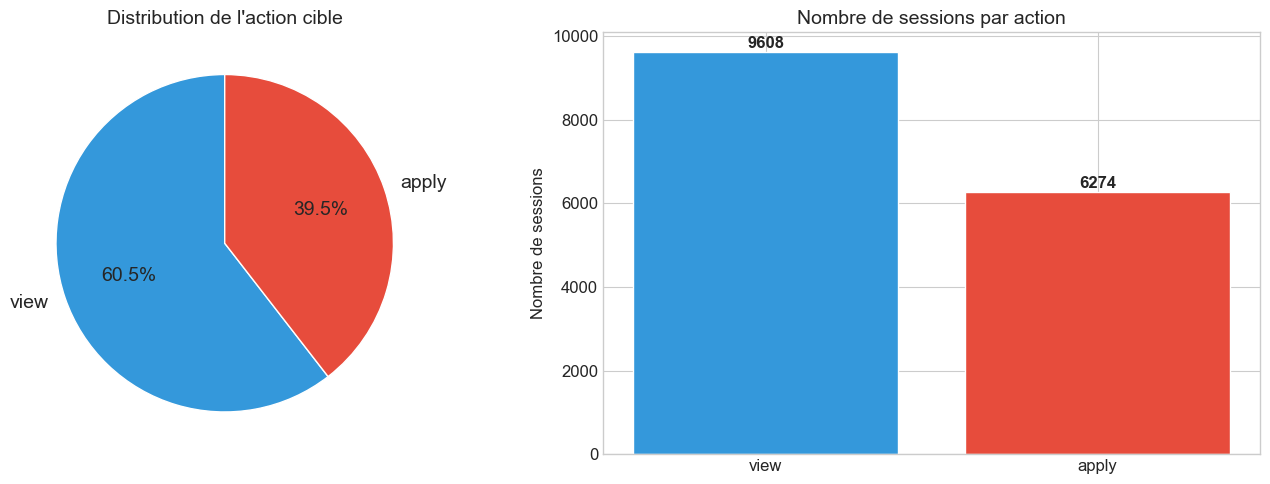


Le dataset est légèrement déséquilibré : environ 60 % de view contre 40 % d'apply.
Ce déséquilibre reste modéré et ne nécessite pas nécessairement de techniques de rééchantillonnage.


In [ ]:
print("--- y_train (premières lignes) ---")
print(y_train.head(5))
print()

# Distribution de la variable cible
print("=" * 50)
print("Distribution de la variable cible (action) :")
print("=" * 50)
action_counts = y_train['action'].value_counts()
print(action_counts)
print(f"\nProportion view  : {action_counts['view'] / len(y_train):.2%}")
print(f"Proportion apply : {action_counts['apply'] / len(y_train):.2%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(action_counts.values, labels=action_counts.index, autopct='%1.1f%%',
           colors=['#3498db', '#e74c3c'], startangle=90, textprops={'fontsize': 14})
axes[0].set_title("Distribution de l'action cible", fontsize=14)

# Bar chart
axes[1].bar(action_counts.index, action_counts.values, color=['#3498db', '#e74c3c'])
axes[1].set_title("Nombre de sessions par action", fontsize=14)
axes[1].set_ylabel("Nombre de sessions")
for i, v in enumerate(action_counts.values):
    axes[1].text(i, v + 100, str(v), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nLe dataset est légèrement déséquilibré : environ 60 % de view contre 40 % d'apply.")
print("Ce déséquilibre reste modéré et ne nécessite pas nécessairement de techniques de rééchantillonnage.")

### Analyse de la variable cible `y_train`

L’examen des premières lignes de `y_train` montre que ce fichier associe à chaque `session_id` deux informations cibles :
- le **`job_id` cible**, c’est-à-dire le prochain emploi consulté par le candidat ;
- l’**`action` cible**, qui indique si ce prochain emploi est simplement *view* ou bien *apply*.

Cette structure confirme que la base d’entraînement permet de traiter simultanément les deux objectifs du challenge : la **recommandation du prochain emploi** et la **prédiction de l’action associée**.

L’analyse de la variable `action` met en évidence une répartition de **9 608 observations de type `view`** contre **6 274 observations de type `apply`**, soit respectivement **60,5 %** et **39,5 %** du jeu d’entraînement. Le dataset est donc **légèrement déséquilibré** en faveur de la classe *view*.

Ce déséquilibre reste toutefois **modéré**. Il est suffisamment marqué pour justifier une certaine vigilance dans l’évaluation des modèles, mais il n’est pas extrême au point d’imposer d’emblée des techniques de rééchantillonnage comme l’oversampling ou l’undersampling. Dans ce contexte, des métriques complémentaires à l’accuracy, comme le **F1-score** ou l’**AUC-ROC**, sont particulièrement utiles pour vérifier que les modèles ne se contentent pas de favoriser la classe majoritaire.

D’un point de vue métier, cette distribution est cohérente : sur un jobboard, il est naturel que les candidats **consultent plus souvent des offres qu’ils ne postulent réellement**. La décision de postuler constitue en effet un engagement plus fort qu’une simple consultation, ce qui explique que la classe *apply* soit moins fréquente.

Enfin, cette légère asymétrie justifie le recours, dans la suite de l’analyse, à une **stratification** lors du découpage train/validation, afin de conserver dans chaque sous-échantillon une proportion de classes similaire à celle observée dans le jeu complet.

Statistiques sur la longueur des sessions :
          count      mean       std  min  25%  50%   75%   max
n_jobs  15882.0  7.539793  3.577731  3.0  4.0  7.0  10.0  15.0



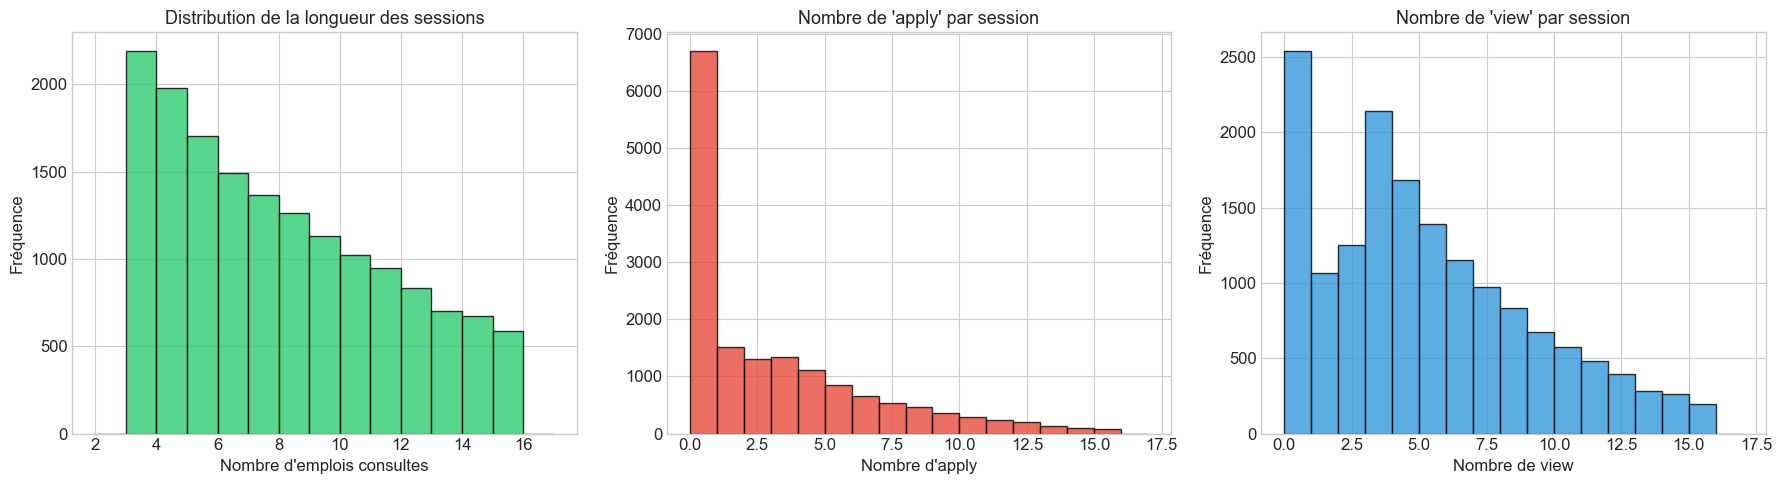


Emplois uniques dans x_train : 20505
Sessions uniques : 15882


In [ ]:
# --- Statistiques de base sur les sessions ---
x_train['n_jobs'] = x_train['job_ids'].apply(len)
x_train['n_apply'] = x_train['actions'].apply(lambda a: sum(1 for x in a if x == 'apply'))
x_train['n_view']  = x_train['actions'].apply(lambda a: sum(1 for x in a if x == 'view'))

print("Statistiques sur la longueur des sessions :")
print(x_train['n_jobs'].describe().to_frame().T)
print()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution des longueurs de session
axes[0].hist(x_train['n_jobs'], bins=range(2, 18), color='#2ecc71', edgecolor='black', alpha=0.8)
axes[0].set_title("Distribution de la longueur des sessions", fontsize=13)
axes[0].set_xlabel("Nombre d'emplois consultes")
axes[0].set_ylabel("Fréquence")

# Distribution du nombre d'apply par session
axes[1].hist(x_train['n_apply'], bins=range(0, 18), color='#e74c3c', edgecolor='black', alpha=0.8)
axes[1].set_title("Nombre de 'apply' par session", fontsize=13)
axes[1].set_xlabel("Nombre d'apply")
axes[1].set_ylabel("Fréquence")

# Distribution du nombre de view par session
axes[2].hist(x_train['n_view'], bins=range(0, 18), color='#3498db', edgecolor='black', alpha=0.8)
axes[2].set_title("Nombre de 'view' par session", fontsize=13)
axes[2].set_xlabel("Nombre de view")
axes[2].set_ylabel("Fréquence")

plt.tight_layout()
plt.show()

# Nombre d'emplois uniques
all_job_ids = set()
for jobs in x_train['job_ids']:
    all_job_ids.update(jobs)
print(f"\nEmplois uniques dans x_train : {len(all_job_ids)}")
print(f"Sessions uniques : {x_train['session_id'].nunique()}")

### Analyse descriptive des sessions de navigation

L’étude de la longueur des sessions montre que chaque candidat consulte en moyenne **7,54 emplois** par session, avec une médiane de **7 emplois**. La session la plus courte contient **3 emplois**, tandis que la plus longue en comporte **15**. L’écart-type de **3,58** indique une dispersion non négligeable, ce qui signifie que les comportements de navigation sont hétérogènes d’un candidat à l’autre.

L’histogramme de la longueur des sessions met en évidence une concentration des observations autour des sessions de taille intermédiaire, avec une fréquence plus élevée pour les sessions relativement courtes, puis une diminution progressive lorsque le nombre d’emplois consultés augmente. Cela suggère que la plupart des candidats explorent un nombre limité d’offres avant d’interrompre leur navigation, tandis qu’une minorité adopte un comportement d’exploration plus approfondi.

L’analyse du nombre d’actions *apply* par session révèle qu’un grand nombre de sessions contiennent **peu ou pas de candidatures**, ce qui est cohérent avec la logique d’un jobboard : consulter une offre constitue un comportement beaucoup plus fréquent que candidater effectivement. À l’inverse, certaines sessions présentent plusieurs actions *apply*, ce qui traduit des comportements plus engagés et potentiellement des candidats plus avancés dans leur recherche.

Le nombre de *view* par session est plus étalé, ce qui confirme que la consultation d’offres constitue l’activité dominante dans les parcours observés. Cette dissymétrie entre *view* et *apply* justifie pleinement la construction de variables comportementales comme le `apply_ratio`, le nombre d’actions récentes, ou encore la dernière action effectuée.

Enfin, le jeu d’entraînement contient **15 882 sessions uniques** et environ **20 505 emplois uniques**, ce qui montre que le problème de recommandation s’inscrit dans un espace d’items très large. Cette forte cardinalité des `job_ids` rend la tâche de recommandation difficile, car il faut identifier le bon emploi parmi un très grand nombre de possibilités. Cela explique pourquoi des approches exploitant à la fois la structure séquentielle des sessions et les similarités entre comportements seront nécessaires pour obtenir un bon score en MRR.

## 4. Construction des Features (Feature Engineering)

L’étape de feature engineering est cruciale dans tout projet de Machine Learning. Comme le rappelle le chapitre 1 du cours, la qualité des features est souvent plus déterminante que le choix de l’algorithme : un bon encodage des données permet même à un modèle simple d’atteindre de bonnes performances, tandis qu’un mauvais encodage pénalise les modèles les plus sophistiqués.

Ici, nous ne disposons pas de données tabulaires classiques, mais d’**historiques de navigation séquentiels**. Il faut donc transformer chaque session en un vecteur de features numériques exploitable par nos modèles. Chaque feature est conçue pour capturer un aspect du **comportement du candidat** ou des **caractéristiques des emplois consultés**.

Nous avons construit les variables explicatives suivantes, regroupées par catégorie :

### Features de session (comportement du candidat)
| Feature | Description |
|---------|-------------|
| `n_jobs` | Nombre total d’emplois consultés dans la session |
| `n_apply` / `n_view` | Nombre d’actions *apply* et *view* dans la session |
| `apply_ratio` | Proportion d’*apply* parmi toutes les actions de la session |
| `last_action_is_apply` | Indicateur binaire : 1 si la dernière action est un *apply*, 0 sinon |
| `first_action_is_apply` | Indicateur binaire : 1 si la première action est un *apply* |
| `last_3_apply_count` | Nombre d’*apply* parmi les 3 dernières actions (contexte récent) |
| `last_5_apply_count` | Nombre d’*apply* parmi les 5 dernières actions (contexte élargi) |
| `apply_trend` | Différence du taux d’*apply* entre la 2e moitié et la 1re moitié de la session (tendance) |

### Features de popularité (caractéristiques des emplois consultés)
| Feature | Description |
|---------|-------------|
| `mean_job_pop` / `max_job_pop` / `min_job_pop` | Popularité moyenne, max et min des emplois consultés |
| `std_job_pop` | Écart-type de la popularité (hétérogénéité des emplois consultés) |
| `last_job_pop` / `first_job_pop` | Popularité du dernier et du premier emploi consulté |
| `mean_apply_rate_jobs` | Taux moyen d’*apply* des emplois de la session |
| `max_apply_rate_jobs` / `last_job_apply_rate` | Taux d’*apply* max et du dernier emploi |

### Features de diversité
| Feature | Description |
|---------|-------------|
| `session_diversity` | Ratio emplois uniques / total (mesure si le candidat revient sur les mêmes offres) |

Ces features sont construites **uniquement** à partir des données de navigation, sans information de profil du candidat. L’intuition est qu’un candidat qui a tendance à postuler dans sa session actuelle continuera probablement à postuler sur le prochain emploi. Ce type de raisonnement relève de l’**hypothèse i.i.d.** (*identically and independently distributed*) : on suppose que les observations futures suivent des patterns similaires à celles observées dans le passé.

In [ ]:
# --- Calculer la popularité globale des emplois (sur tout le train) ---
job_pop = Counter()
job_apply_count = Counter()
job_total_count = Counter()

for jobs, actions in zip(x_train['job_ids'], x_train['actions']):
    for j, a in zip(jobs, actions):
        job_pop[j] += 1
        job_total_count[j] += 1
        if a == 'apply':
            job_apply_count[j] += 1

# Taux d'apply par emploi
job_apply_rate = {j: job_apply_count[j] / job_total_count[j] for j in job_total_count}

# Popularité aussi des emplois ciblés
for j in y_train['job_id']:
    job_pop[j] += 1

print(f"Nombre d'emplois distincts avec statistiques de popularite : {len(job_pop)}")
print(f"   Popularite moyenne d'un emploi : {np.mean(list(job_pop.values())):.1f}")
print(f"   Popularite mediane d'un emploi : {np.median(list(job_pop.values())):.1f}")
print(f"   Popularite max : {max(job_pop.values())}")

Nombre d'emplois distincts avec statistiques de popularite : 20967
   Popularite moyenne d'un emploi : 6.5
   Popularite mediane d'un emploi : 2.0
   Popularite max : 204


### Analyse de la popularité des emplois

Le calcul des statistiques de popularité montre que le jeu d’entraînement contient **20 967 emplois distincts** pour lesquels il est possible d’estimer une fréquence d’apparition dans les sessions. La **popularité moyenne** d’un emploi est de **6,5 consultations**, tandis que la **médiane** n’est que de **2**. L’écart important entre moyenne et médiane révèle une distribution **très asymétrique** : une grande majorité des emplois apparaissent peu souvent, tandis qu’un petit nombre d’offres concentre une part importante des interactions.

Cette intuition est confirmée par la **popularité maximale**, qui atteint **204 occurrences** pour l’emploi le plus fréquent. Le marché observé dans les données semble donc caractérisé par une forte hétérogénéité entre emplois très visibles et emplois beaucoup plus rares. Ce phénomène est classique dans les systèmes de recommandation, où certains items captent une grande partie de l’attention tandis qu’une longue traîne d’items n’est consultée qu’occasionnellement.

Ces résultats justifient pleinement l’introduction de features de popularité comme `mean_job_pop`, `max_job_pop`, `min_job_pop`, `std_job_pop`, `first_job_pop` ou `last_job_pop`. En effet, la popularité des emplois consultés peut renseigner sur le comportement du candidat : consulter principalement des offres très populaires peut traduire une navigation plus généraliste, alors qu’une session orientée vers des offres rares peut refléter une recherche plus ciblée ou spécialisée.

Enfin, cette forte asymétrie de popularité rappelle que le problème de recommandation est structurellement difficile. Dans un univers de plus de 20 000 emplois distincts, la simple fréquence globale ne suffit pas à recommander efficacement le bon emploi suivant ; il faut également tenir compte du contexte séquentiel et du comportement spécifique observé dans la session.

In [ ]:
def build_features(df, y_df=None):
    """
    Construit les features pour chaque session a partir de l'historique de navigation.
    
    Parameters:
        df: DataFrame avec colonnes ['session_id', 'job_ids', 'actions']
        y_df: DataFrame cible optionnel avec ['session_id', 'job_id', 'action']
    
    Returns:
        DataFrame de features, Series cible (si y_df fourni)
    """
    features = []
    
    for idx, row in df.iterrows():
        jobs = list(row['job_ids'])
        actions = list(row['actions'])
        n = len(jobs)
        
        n_apply = sum(1 for a in actions if a == 'apply')
        n_view  = sum(1 for a in actions if a == 'view')
        
        # Popularité des emplois de la session
        pops = [job_pop.get(j, 0) for j in jobs]
        apply_rates = [job_apply_rate.get(j, 0.0) for j in jobs]
        
        feat = {
            'session_id': row['session_id'],
            # --- Features de session ---
            'n_jobs': n,
            'n_apply': n_apply,
            'n_view': n_view,
            'apply_ratio': n_apply / n if n > 0 else 0.0,
            'last_action_is_apply': 1 if actions[-1] == 'apply' else 0,
            'first_action_is_apply': 1 if actions[0] == 'apply' else 0,
            
            # Contexte recent (dernièeres 3 actions)
            'last_3_apply_count': sum(1 for a in actions[-3:] if a == 'apply'),
            'last_3_view_count': sum(1 for a in actions[-3:] if a == 'view'),
            
            # Contexte plus large (dernières 5 actions)
            'last_5_apply_count': sum(1 for a in actions[-5:] if a == 'apply'),
            
            # --- Features de popularité ---
            'mean_job_pop': np.mean(pops),
            'max_job_pop': np.max(pops),
            'min_job_pop': np.min(pops),
            'std_job_pop': np.std(pops) if len(pops) > 1 else 0.0,
            'last_job_pop': pops[-1],
            'first_job_pop': pops[0],
            
            # --- Taux d'apply des emplois ---
            'mean_apply_rate_jobs': np.mean(apply_rates),
            'max_apply_rate_jobs': np.max(apply_rates),
            'last_job_apply_rate': apply_rates[-1],
            
            # --- Diversité ---
            'session_diversity': len(set(jobs)) / n if n > 0 else 0.0,
            
            # --- Tendance (est-ce que le candidat applique de plus en plus ?) ---
            'apply_trend': (sum(1 for a in actions[n//2:] if a == 'apply') / max(len(actions[n//2:]), 1)
                          - sum(1 for a in actions[:n//2] if a == 'apply') / max(len(actions[:n//2]), 1)),
        }
        features.append(feat)
    
    feat_df = pd.DataFrame(features)
    
    if y_df is not None:
        merged = feat_df.merge(y_df[['session_id', 'job_id', 'action']], on='session_id', how='left')
        # Ajouter la popularite de l'emploi cible
        merged['target_job_pop'] = merged['job_id'].map(job_pop).fillna(0)
        merged['target_job_apply_rate'] = merged['job_id'].map(job_apply_rate).fillna(0)
        y = merged['action'].map({'view': 0, 'apply': 1})
        return merged.drop(columns=['job_id', 'action']), y
    
    return feat_df, None

# Construire les features pour le train
print("Construction des features pour x_train...")
X_full, y_full = build_features(x_train, y_train)

# Colonnes de features (excluant session_id)
feature_cols = [c for c in X_full.columns if c not in ['session_id', 'target_job_pop', 'target_job_apply_rate']]
print(f"{len(feature_cols)} features creees : {feature_cols}")
print(f"   Shape X_full : {X_full.shape}")
print(f"   Distribution y : {Counter(y_full.values)}")

Construction des features pour x_train...
20 features creees : ['n_jobs', 'n_apply', 'n_view', 'apply_ratio', 'last_action_is_apply', 'first_action_is_apply', 'last_3_apply_count', 'last_3_view_count', 'last_5_apply_count', 'mean_job_pop', 'max_job_pop', 'min_job_pop', 'std_job_pop', 'last_job_pop', 'first_job_pop', 'mean_apply_rate_jobs', 'max_apply_rate_jobs', 'last_job_apply_rate', 'session_diversity', 'apply_trend']
   Shape X_full : (15882, 23)
   Distribution y : Counter({np.int64(0): 9608, np.int64(1): 6274})


In [ ]:
# --- Statistiques descriptives des features ---
print("Statistiques descriptives des features :")
X_full[feature_cols].describe().round(3)

Statistiques descriptives des features :


,n_jobs,n_apply,n_view,apply_ratio,last_action_is_apply,first_action_is_apply,last_3_apply_count,last_3_view_count,last_5_apply_count,mean_job_pop,max_job_pop,min_job_pop,std_job_pop,last_job_pop,first_job_pop,mean_apply_rate_jobs,max_apply_rate_jobs,last_job_apply_rate,session_diversity,apply_trend
count,15882.000,15882.000,15882.000,15882.000,15882.000,15882.000,15882.000,15882.000,15882.000,15882.000,15882.000,15882.000,15882.000,15882.000,15882.000,15882.000,15882.000,15882.000,15882.000,15882.000
mean,7.540,2.747,4.793,0.357,0.394,0.303,1.155,1.845,1.746,32.962,70.545,10.635,19.960,33.241,33.185,0.364,0.559,0.367,0.995,0.057
std,3.578,3.477,3.842,0.386,0.489,0.460,1.285,1.285,1.945,23.919,52.905,11.642,15.730,35.052,34.916,0.187,0.255,0.243,0.036,0.346
min,3.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000,1.000,0.000,1.000,1.000,0.000,0.000,0.000,0.500,-1.000
25%,4.000,0.000,2.000,0.000,0.000,0.000,0.000,0.000,0.000,11.143,23.000,2.000,6.056,7.000,7.000,0.297,0.491,0.200,1.000,0.000
50%,7.000,1.000,4.000,0.231,0.000,0.000,1.000,2.000,1.000,31.542,62.000,7.000,17.215,22.000,22.000,0.402,0.600,0.394,1.000,0.000
75%,10.000,4.000,7.000,0.692,1.000,1.000,3.000,3.000,3.000,48.325,106.000,15.000,30.120,47.750,48.000,0.481,0.692,0.520,1.000,0.000
max,15.000,15.000,15.000,1.000,1.000,1.000,3.000,3.000,5.000,157.333,204.000,123.000,88.077,204.000,204.000,1.000,1.000,1.000,1.000,1.000


### Interprétation des features construites

La phase de feature engineering permet de transformer chaque session de navigation en un **vecteur numérique exploitable** par les modèles supervisés. Au total, **20 features** ont été construites à partir des seules données de navigation, ce qui constitue une base d’information riche malgré l’absence de variables de profil candidat. La matrice finale contient **15 882 observations** et **23 colonnes**, ce qui confirme que chaque session a bien été convertie en une représentation structurée adaptée aux modèles de classification.

Les statistiques descriptives montrent d’abord que les features construites reflètent fidèlement les caractéristiques observées lors de l’exploration initiale. En moyenne, une session contient **7,54 emplois consultés**, dont **4,79 vues** et **2,75 candidatures**. Cela confirme que les candidats consultent plus souvent des offres qu’ils n’y postulent, tout en montrant que les actions *apply* restent suffisamment fréquentes pour être informatives dans la prédiction.

Le **`apply_ratio`** présente une moyenne de **0,357**, avec une médiane de **0,231**. Cela indique que, dans de nombreuses sessions, la proportion de candidatures reste relativement faible, tandis qu’un sous-ensemble de sessions présente un comportement plus actif. Cette dispersion suggère l’existence de profils candidats différenciés : certains explorent surtout les offres, alors que d’autres postulent plus rapidement et plus intensément.

Les variables binaires liées à la position des actions dans la session apportent également une information importante. La feature **`last_action_is_apply`** a une moyenne de **0,394**, ce qui signifie qu’environ **39,4 %** des sessions se terminent par une candidature. De même, **`first_action_is_apply`** a une moyenne de **0,303**, ce qui montre qu’il est plus rare qu’un candidat commence directement sa session par une action *apply*. Ce résultat est cohérent d’un point de vue comportemental : la candidature intervient plus souvent après une phase préalable d’exploration.

Les features de contexte récent confirment cette logique. Le **`last_3_apply_count`** a une moyenne de **1,155**, tandis que le **`last_3_view_count`** a une moyenne de **1,845**. De même, **`last_5_apply_count`** présente une moyenne de **1,746** et une médiane de **1**. Autrement dit, même dans les dernières interactions, les consultations restent majoritaires, mais les candidatures sont loin d’être marginales. Ces variables sont donc particulièrement utiles pour capter le **niveau d’engagement récent** du candidat, potentiellement plus prédictif que des mesures calculées sur l’ensemble de la session.

Les features de **popularité des emplois** montrent ensuite une forte hétérogénéité. La **popularité moyenne** des emplois consultés dans une session (`mean_job_pop`) est de **32,96**, tandis que la popularité maximale (`max_job_pop`) atteint en moyenne **70,55**. À l’inverse, la popularité minimale (`min_job_pop`) n’est en moyenne que de **10,64**. Cela signifie qu’une même session peut combiner des offres très visibles et d’autres beaucoup plus confidentielles. L’**écart-type de popularité** (`std_job_pop`), de moyenne **19,96**, confirme cette diversité interne : les candidats ne consultent pas nécessairement des emplois homogènes en termes de visibilité.

Les variables **`first_job_pop`** et **`last_job_pop`** présentent des moyennes très proches (respectivement **33,19** et **33,24**), ce qui suggère qu’en moyenne, les sessions ne commencent ni ne se terminent sur des emplois systématiquement plus populaires. La popularité brute du premier ou du dernier emploi ne semble donc pas, à elle seule, traduire une orientation comportementale claire, mais elle peut néanmoins interagir avec d’autres variables.

Les variables liées au **taux d’apply des emplois consultés** sont également très informatives. Le **taux moyen d’apply** des emplois de la session (`mean_apply_rate_jobs`) est de **0,364**, tandis que le **taux maximal** (`max_apply_rate_jobs`) atteint **0,559** en moyenne. Le **taux d’apply du dernier emploi** (`last_job_apply_rate`) est proche de **0,367**. Ces résultats montrent que les sessions comportent souvent des offres qui, historiquement, suscitent plus ou moins de candidatures. Ces variables introduisent donc une information utile non seulement sur le comportement du candidat, mais aussi sur l’attrait relatif des emplois consultés.

La variable **`session_diversity`** est particulièrement révélatrice : sa moyenne est de **0,995**, avec une médiane égale à **1**. Cela signifie que, dans l’immense majorité des cas, les candidats consultent **des emplois distincts sans revenir plusieurs fois sur les mêmes offres**. Les sessions sont donc très majoritairement des parcours d’exploration plutôt que de revisite. Ce résultat est important, car il suggère que le comportement observé est dominé par une logique de découverte successive d’offres.

Enfin, la variable **`apply_trend`** a une moyenne légèrement positive (**0,057**), mais une médiane égale à **0**. Cela indique qu’en moyenne, il existe une légère tendance à candidater davantage dans la seconde moitié de la session, sans que cet effet soit massif. L’existence de valeurs comprises entre **-1** et **1** montre cependant que certaines sessions présentent une évolution marquée du comportement : certains candidats deviennent plus actifs au fil de leur navigation, tandis que d’autres font l’inverse. Cette variable est donc utile pour capter une **dynamique intra-session**, cohérente avec l’idée du challenge selon laquelle les préférences des candidats peuvent évoluer pendant la navigation.

Dans l’ensemble, ces statistiques montrent que les features construites sont **cohérentes avec la logique métier du problème**. Elles capturent à la fois :
- l’**intensité de navigation** (`n_jobs`, `n_view`, `n_apply`) ;
- le **degré d’engagement** du candidat (`apply_ratio`, `last_action_is_apply`) ;
- le **contexte récent** de la session (`last_3_apply_count`, `last_5_apply_count`) ;
- les **caractéristiques des emplois consultés** (popularité, taux d’apply) ;
- la **diversité du parcours** (`session_diversity`) ;
- et la **dynamique temporelle du comportement** (`apply_trend`).

Cette étape est donc centrale, car elle permet de résumer un historique séquentiel complexe sous une forme informative, tout en conservant les signaux comportementaux les plus pertinents pour prédire l’action suivante.

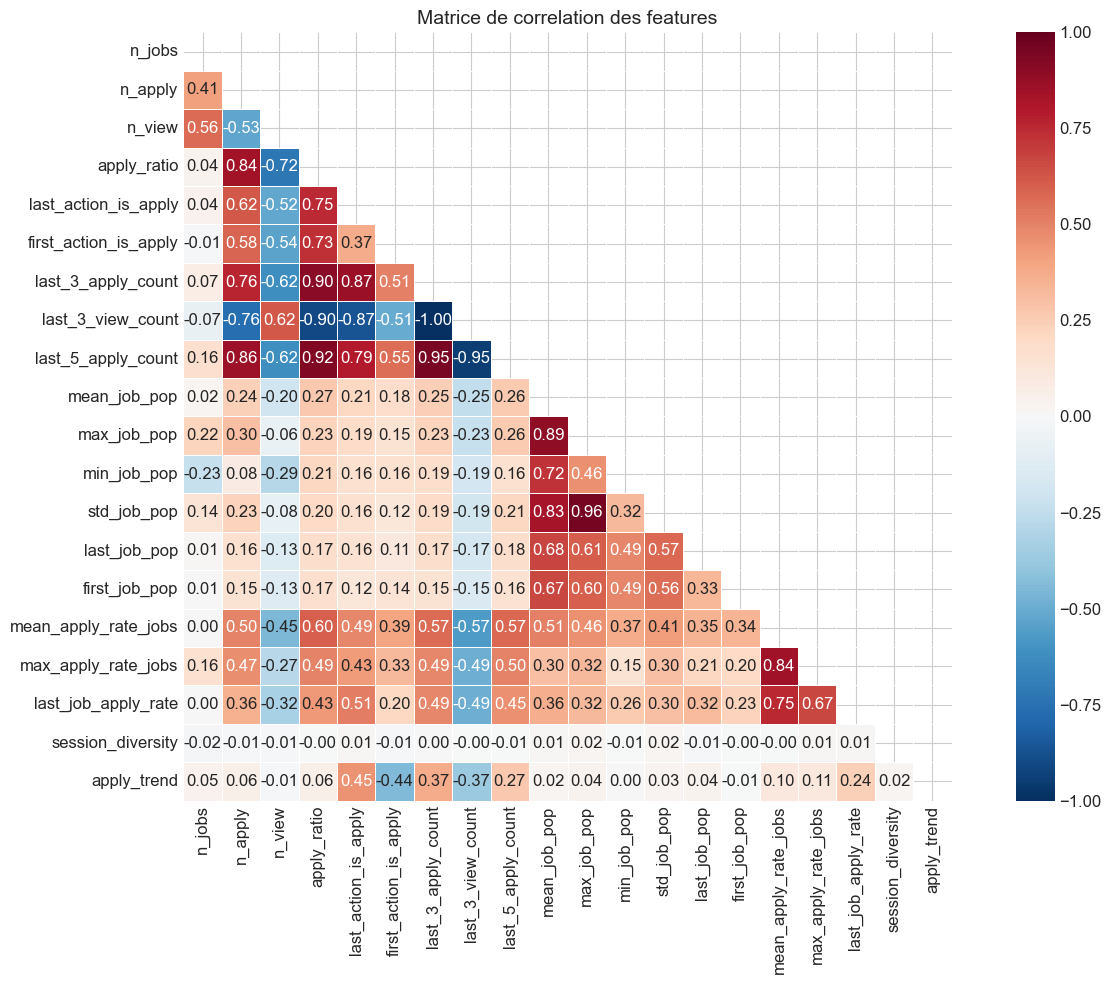

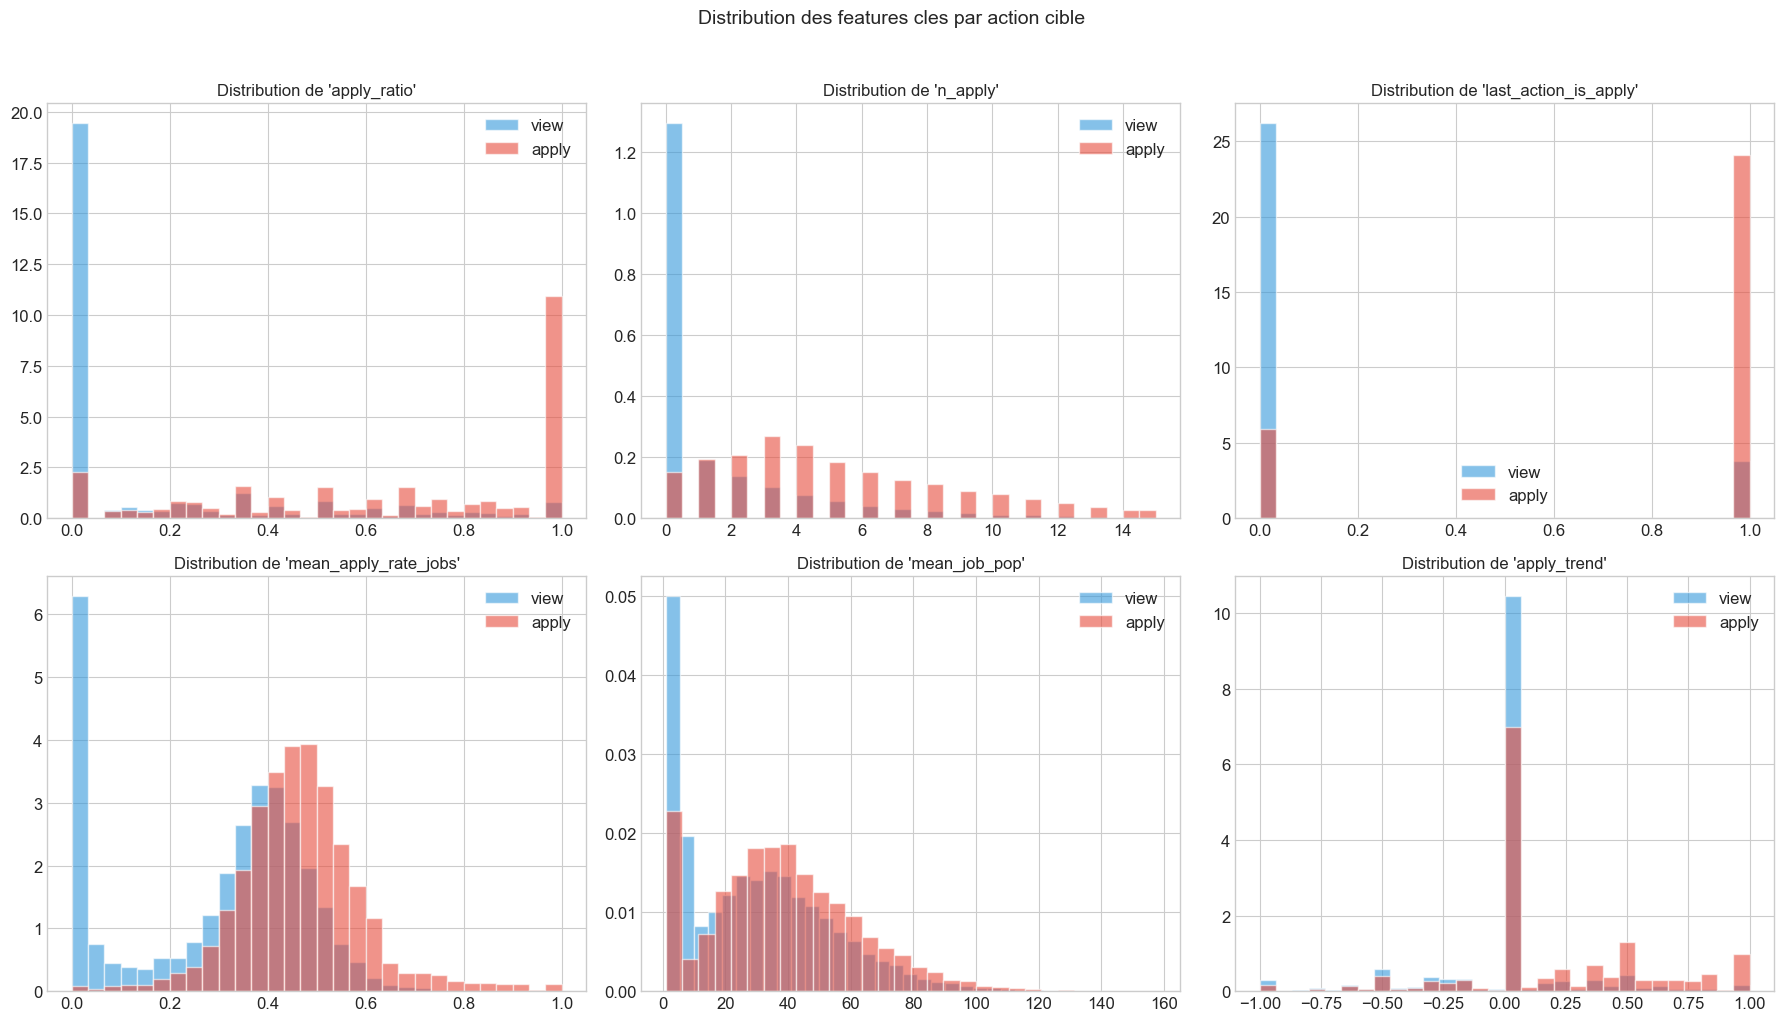

On observe que les features liées au comportement d'apply (apply_ratio, last_action_is_apply)
montrent une séparation nette entre les classes view et apply.
Cela confirme notre intuition : le comportement passé d'un candidat est un bon prédicteur de son action future.


In [ ]:
# --- Matrice de correlation ---
fig, ax = plt.subplots(figsize=(14, 10))
corr = X_full[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("Matrice de correlation des features", fontsize=14)
plt.tight_layout()
plt.show()

# --- Distribution des features par classe ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
key_features = ['apply_ratio', 'n_apply', 'last_action_is_apply', 
                'mean_apply_rate_jobs', 'mean_job_pop', 'apply_trend']

for ax, feat in zip(axes.flatten(), key_features):
    for label, color in [(0, '#3498db'), (1, '#e74c3c')]:
        subset = X_full.loc[y_full == label, feat]
        ax.hist(subset, bins=30, alpha=0.6, color=color, 
                label='view' if label == 0 else 'apply', density=True)
    ax.set_title(f"Distribution de '{feat}'", fontsize=12)
    ax.legend()

plt.suptitle("Distribution des features cles par action cible", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("On observe que les features liées au comportement d'apply (apply_ratio, last_action_is_apply)")
print("montrent une séparation nette entre les classes view et apply.")
print("Cela confirme notre intuition : le comportement passé d'un candidat est un bon prédicteur de son action future.")

### Analyse de la matrice de corrélation des features

La matrice de corrélation permet d’examiner les relations linéaires entre les variables construites et d’identifier d’éventuelles redondances. Globalement, les résultats sont cohérents avec la logique de construction des features : plusieurs variables mesurent des dimensions proches du comportement candidat, ce qui explique l’existence de corrélations parfois élevées.

Un premier groupe de corrélations fortes concerne naturellement les variables décrivant l’**intensité et la composition de la session**. Par exemple, `n_apply` est fortement corrélée à `apply_ratio`, à `last_3_apply_count` et à `last_5_apply_count`, ce qui est attendu puisque ces variables traduisent toutes, sous des angles différents, l’intensité de candidature dans la session. De même, `n_view` est fortement et négativement corrélée à plusieurs variables centrées sur les candidatures, ce qui reflète le fait qu’une session dominée par les *view* est mécaniquement moins orientée vers les *apply*.

On observe également une très forte corrélation négative entre `last_3_apply_count` et `last_3_view_count`, proche de **-1**, ce qui est logique puisque, sur les trois dernières interactions, une hausse du nombre d’`apply` implique mécaniquement une baisse du nombre de `view`. Cette relation confirme que ces variables capturent deux faces d’un même signal comportemental récent.

Les variables de **popularité des emplois** forment elles aussi un bloc relativement corrélé. `mean_job_pop`, `max_job_pop`, `std_job_pop`, `first_job_pop` et `last_job_pop` présentent des corrélations positives parfois élevées, ce qui suggère que les sessions orientées vers des emplois populaires ont tendance à rester globalement situées dans cet univers d’offres visibles. Toutefois, les corrélations ne sont pas parfaites, ce qui indique que chaque variable apporte malgré tout une information complémentaire : niveau moyen de popularité, extrêmes, dispersion interne, ou position dans la séquence.

Les variables liées au **taux d’apply des emplois** (`mean_apply_rate_jobs`, `max_apply_rate_jobs`, `last_job_apply_rate`) sont également positivement corrélées entre elles, ce qui est cohérent puisque ces mesures décrivent différentes facettes d’une même propension historique des emplois à susciter une candidature. Là encore, il existe une redondance partielle mais non totale.

À l’inverse, certaines variables apparaissent beaucoup plus indépendantes. C’est notamment le cas de **`session_diversity`**, qui présente des corrélations très faibles avec l’ensemble des autres features. Cela signifie que la diversité du parcours apporte une information relativement orthogonale au reste des variables. La feature **`apply_trend`** est elle aussi modérément corrélée aux autres variables, ce qui confirme qu’elle capte une dimension spécifique : l’évolution du comportement de candidature au cours de la session.

D’un point de vue méthodologique, cette matrice suggère donc l’existence d’une **multicolinéarité partielle** entre certaines variables, en particulier dans les blocs liés au volume d’actions, à la récence et à la popularité. Cela ne pose pas de problème majeur pour les modèles ensemblistes comme le **Random Forest** ou **XGBoost**, qui sont généralement robustes à ce type de redondance. En revanche, pour des modèles plus sensibles comme la **régression logistique** ou le **SVM**, cette structure justifie le recours à la **standardisation** et, si nécessaire, à la **régularisation**, afin de limiter l’instabilité des coefficients.

En définitive, la matrice de corrélation confirme que les features construites sont à la fois **cohérentes** et **complémentaires** : certaines sont volontairement proches car elles décrivent différentes nuances d’un même comportement, tandis que d’autres apportent une information plus originale sur la diversité ou la dynamique de session. Cette structure est favorable à l’apprentissage, à condition d’utiliser des modèles capables de gérer efficacement cette redondance partielle.

### Analyse des distributions des features clés selon l’action cible

L’examen des distributions des variables clés selon la classe cible (*view* ou *apply*) permet d’évaluer visuellement leur **pouvoir discriminant**. Plusieurs features présentent en effet des profils très différents selon l’action prédite, ce qui confirme leur pertinence pour la tâche de classification.

La variable **`apply_ratio`** apparaît comme l’une des plus informatives. Les sessions associées à la classe *view* sont très fortement concentrées autour de valeurs faibles, souvent proches de **0**, tandis que les sessions de classe *apply* sont davantage réparties sur des valeurs plus élevées, avec une concentration visible vers **1**. Cela signifie qu’un candidat ayant déjà beaucoup postulé au cours de sa session a une probabilité plus forte de postuler également sur l’emploi suivant. Cette variable capture donc très bien le **degré global d’engagement** du candidat.

La distribution de **`n_apply`** confirme cette lecture. Les sessions menant à une action *view* sont surreprésentées pour des valeurs faibles, voire nulles, alors que les sessions menant à une action *apply* présentent une distribution plus étalée vers les valeurs élevées. Le nombre brut de candidatures déjà effectuées dans la session constitue ainsi un signal comportemental fort.

La feature binaire **`last_action_is_apply`** est particulièrement discriminante. On observe clairement que lorsque la dernière action de la session est un *apply*, la probabilité que l’action cible soit elle aussi un *apply* augmente fortement. À l’inverse, lorsque la dernière action est un *view*, la classe *view* domine nettement. Ce résultat est cohérent avec l’idée d’une **inertie comportementale locale** : le comportement très récent du candidat est souvent révélateur de son action suivante.

Les variables liées aux caractéristiques des emplois consultés apportent également une information utile. La distribution de **`mean_apply_rate_jobs`** est légèrement décalée vers des valeurs plus élevées pour la classe *apply*, ce qui suggère que les sessions qui aboutissent à une candidature contiennent plus souvent des offres historiquement propices à la candidature. Autrement dit, la propension moyenne des emplois de la session à générer des *apply* semble bien liée à l’action future du candidat.

La variable **`mean_job_pop`** montre aussi un certain décalage entre les deux classes, même si la séparation paraît moins nette que pour les variables directement comportementales. Cela suggère que la popularité moyenne des emplois consultés joue un rôle, mais probablement de manière secondaire ou en interaction avec d’autres signaux.

Enfin, la distribution de **`apply_trend`** montre que les sessions associées à *apply* ont plus souvent une tendance positive, c’est-à-dire une augmentation relative du comportement de candidature dans la seconde moitié de la session. À l’inverse, les sessions menant à *view* restent davantage concentrées autour de **0**. Cette feature semble donc capter une **dynamique temporelle utile**, même si son pouvoir discriminant visuel paraît plus modéré que celui de `apply_ratio` ou de `last_action_is_apply`.

Dans l’ensemble, ces histogrammes confirment que les variables les plus utiles pour la classification sont principalement celles qui décrivent :
- le **niveau d’engagement global** du candidat (`apply_ratio`, `n_apply`) ;
- le **contexte comportemental récent** (`last_action_is_apply`) ;
- et, dans une moindre mesure, les **caractéristiques des emplois consultés** (`mean_apply_rate_jobs`, `mean_job_pop`) ainsi que la **dynamique de session** (`apply_trend`).

Cette lecture visuelle est cohérente avec les résultats attendus des modèles supervisés : les features comportementales directes semblent être les plus discriminantes, tandis que les variables liées aux emplois jouent plutôt un rôle de complément explicatif.

## 5. Décomposition Train / Validation / Test

Le jeu de données est déjà naturellement décomposé en un **échantillon d’entraînement** (`x_train` / `y_train`) et un **échantillon de test** (`x_test`, sans labels). Cependant, pour pouvoir évaluer nos modèles en local avant la soumission, nous décomposons nous-mêmes le jeu de train en deux parties :

- **Train d’estimation** (80 %) : utilisé pour entraîner les modèles.
- **Validation** (20 %) : utilisée pour évaluer les performances et comparer les modèles, sans biais de sur-apprentissage.

Cette décomposition est essentielle pour gérer le **trade-off biais-variance**. Un modèle trop simple (biais élevé) sous-apprend les données (*underfitting*), tandis qu’un modèle trop complexe (variance élevée) sur-apprend le bruit du jeu de train (*overfitting*) et ne généralise pas bien sur des données nouvelles. L’erreur de généralisation se décompose formellement en :

$$
\text{Erreur} = \text{Biais}^2 + \text{Variance} + \text{Bruit irréductible}
$$

Le jeu de validation permet d’estimer cette erreur de généralisation et de détecter un éventuel sur-apprentissage en comparant les performances train vs validation.

Nous appliquons une **stratification** sur la variable cible `y` lors du split, afin de garantir que la proportion *view*/*apply* est conservée dans les deux partitions. C’est important étant donné le léger déséquilibre observé précédemment.

Par ailleurs, nous **standardisons** les features (centrage-réduction via `StandardScaler`) car certains modèles comme la régression logistique et le SVM sont sensibles à l’échelle des variables. Le chapitre S1 du cours (*SVM*) insiste sur ce point : le SVM calcule des distances entre points, donc des features sur des échelles différentes biaiseraient la frontière de décision.

In [ ]:
# --- Split Train / Validation ---
X_feats = X_full[feature_cols].values
y_labels = y_full.values

X_tr, X_val, y_tr, y_val = train_test_split(
    X_feats, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

# Standardiser les features
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_val_scaled = scaler.transform(X_val)

print(f"Split realise :")
print(f"   Train      : {X_tr.shape[0]} samples ({sum(y_tr==0)} view, {sum(y_tr==1)} apply)")
print(f"   Validation : {X_val.shape[0]} samples ({sum(y_val==0)} view, {sum(y_val==1)} apply)")
print(f"   Test       : {x_test.shape[0]} sessions (pas de labels)")
print(f"\n   Features normalisees (StandardScaler)")

Split realise :
   Train      : 12705 samples (7686 view, 5019 apply)
   Validation : 3177 samples (1922 view, 1255 apply)
   Test       : 1819 sessions (pas de labels)

   Features normalisees (StandardScaler)


### Interprétation du découpage train / validation / test

Le découpage réalisé confirme que la procédure d’évaluation locale a été mise en place de manière cohérente. Le jeu d’entraînement initial a été séparé en un sous-échantillon de **12 705 observations pour l’entraînement** et **3 177 observations pour la validation**, soit une répartition conforme au schéma **80 % / 20 %** annoncé. Le jeu de test contient quant à lui **1 819 sessions**, pour lesquelles aucune cible n’est disponible, ce qui correspond bien au cadre du challenge.

La **stratification** sur la variable cible a correctement préservé la structure de classes observée dans les données initiales. Dans le train, on compte **7 686 observations de type `view`** contre **5 019 de type `apply`** ; dans la validation, **1 922 `view`** contre **1 255 `apply`**. Les proportions restent donc très proches de celles du jeu complet, ce qui est essentiel pour garantir une évaluation fiable des modèles. Sans stratification, un déséquilibre différent entre les sous-échantillons aurait pu biaiser les performances observées, en particulier pour la classe minoritaire *apply*.

Ce découpage est central pour analyser le **pouvoir de généralisation** des modèles. Le sous-échantillon d’entraînement sert à apprendre les relations entre les features et la cible, tandis que le jeu de validation permet de mesurer la capacité du modèle à reproduire ces performances sur des données non vues. La comparaison entre les scores obtenus sur le train et sur la validation permettra ainsi de détecter un éventuel **sur-apprentissage** : un écart trop important entre les deux signalerait un modèle trop complexe ou trop spécifique au jeu d’entraînement.

Par ailleurs, les features ont été **normalisées via `StandardScaler`**, ce qui constitue une étape importante pour les modèles sensibles à l’échelle des variables, comme la **régression logistique**, le **SVM** ou le **MLP**. Cette standardisation permet d’éviter qu’une variable de grande amplitude domine artificiellement les autres dans le processus d’apprentissage. Elle améliore également la stabilité numérique des algorithmes et facilite leur convergence.

En résumé, cette étape de prétraitement fournit un cadre expérimental solide pour comparer les différents modèles de classification. Le découpage stratifié garantit une évaluation équilibrée, tandis que la normalisation assure des conditions d’apprentissage adaptées aux méthodes les plus sensibles à l’échelle des données.

## 6. Modèle de Référence -- Régression Logistique

Pour établir une **baseline**, nous commençons par un modèle simple et interprétable : la **régression logistique**. Ce choix se justifie pour plusieurs raisons :
- C’est un modèle linéaire qui fournit des **coefficients interprétables** (on peut directement lire l’influence de chaque feature).
- Il est rapide à entraîner et peu sujet au sur-apprentissage sur des features bien construites.
- Il constitue un point de comparaison solide pour évaluer l’apport des modèles plus complexes. Comme le rappelle le cours (Chapitre 1), un bon modèle de référence est indispensable avant d’augmenter la complexité.

Nous évaluons ce modèle avec plusieurs métriques complémentaires :
- **Accuracy** : la métrique principale du challenge pour la classification (pondérée à 30 % dans le score final). Elle mesure la proportion de prédictions correctes.
- **F1-Score** : moyenne harmonique de la précision et du rappel. Elle est définie par $F_1 = 2 \times \frac{\text{Précision} \times \text{Rappel}}{\text{Précision} + \text{Rappel}}$. Cette métrique est utile pour mieux apprécier la performance par classe, surtout en cas de déséquilibre.
- **AUC-ROC** : aire sous la courbe ROC (Receiver Operating Characteristic), qui mesure la capacité discriminante du modèle indépendamment du seuil de classification. Une AUC de 0.5 correspond à un classifieur aléatoire, et une AUC de 1.0 à un classifieur parfait.

Nous effectuons également une **validation croisée stratifiée 5-fold** pour estimer la robustesse du modèle. Le principe est de découper le jeu de train en $k=5$ sous-ensembles, d’entraîner le modèle sur $k-1$ folds et de l’évaluer sur le fold restant, en répétant l’opération $k$ fois. La moyenne des scores obtenus fournit une estimation plus fiable de la performance que le simple split train/validation.

In [ ]:
# MODÈLE DE REFERENCE : Regression Logistique

def evaluate_model(model, X_train, y_train, X_val, y_val, model_name="Modele"):
    """Evalue un modele de classification et affiche les resultats."""
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)
    
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_val = accuracy_score(y_val, y_pred_val)
    f1_val = f1_score(y_val, y_pred_val, average='weighted')
    
    print(f"{'=' * 60}")
    print(f"  {model_name}")
    print(f"{'=' * 60}")
    print(f"   Accuracy Train : {acc_train:.4f}")
    print(f"   Accuracy Val   : {acc_val:.4f}")
    print(f"   F1-Score Val   : {f1_val:.4f}")
    
    # Verification du sur-apprentissage
    overfit = acc_train - acc_val
    if overfit > 0.05:
        print(f"   Attention : potentiel sur-apprentissage (ecart = {overfit:.4f})")
    else:
        print(f"   Pas de sur-apprentissage detecte (ecart = {overfit:.4f})")
    
    # AUC si probabilites disponibles
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_proba)
        print(f"   AUC-ROC Val    : {auc:.4f}")
    
    print(f"\n   Classification Report (Validation) :")
    print(classification_report(y_val, y_pred_val, target_names=['view', 'apply']))
    
    return {'acc_train': acc_train, 'acc_val': acc_val, 'f1_val': f1_val, 'model_name': model_name}

# --- Regression Logistique ---
lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr.fit(X_tr_scaled, y_tr)

results_lr = evaluate_model(lr, X_tr_scaled, y_tr, X_val_scaled, y_val, "Regression Logistique")

# Cross-validation
cv_scores = cross_val_score(lr, X_tr_scaled, y_tr, cv=5, scoring='accuracy')
print(f"\nCross-validation 5-fold : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

  Regression Logistique
   Accuracy Train : 0.8427
   Accuracy Val   : 0.8388
   F1-Score Val   : 0.8384
   Pas de sur-apprentissage detecte (ecart = 0.0038)
   AUC-ROC Val    : 0.8983

   Classification Report (Validation) :
              precision    recall  f1-score   support

        view       0.86      0.88      0.87      1922
       apply       0.80      0.78      0.79      1255

    accuracy                           0.84      3177
   macro avg       0.83      0.83      0.83      3177
weighted avg       0.84      0.84      0.84      3177


Cross-validation 5-fold : 0.8420 +/- 0.0025


### Interprétation des résultats de la régression logistique

La régression logistique fournit une **baseline solide** pour la prédiction de l’action cible. Le modèle atteint une **accuracy de 0,8427 sur le train** et de **0,8388 sur la validation**, soit un écart très faible de **0,0038**. Cet écart limité indique l’absence de sur-apprentissage significatif : le modèle généralise correctement aux données non vues, ce qui confirme que les features construites sont informatives et que la complexité du modèle reste bien maîtrisée.

Le **F1-score de validation** s’élève à **0,8384**, ce qui montre que la bonne performance globale ne repose pas uniquement sur la classe majoritaire. Cette métrique est particulièrement importante dans notre contexte, car la classe *view* est plus fréquente que la classe *apply*. Le fait que le F1-score soit très proche de l’accuracy suggère un comportement relativement équilibré du modèle.

L’**AUC-ROC de 0,8983** confirme cette bonne capacité de discrimination. Une valeur aussi proche de 0,9 indique que le modèle parvient efficacement à distinguer les sessions qui débouchent sur un *view* de celles qui débouchent sur un *apply*, indépendamment du seuil de classification choisi. Cela signifie que, même avec une structure linéaire relativement simple, les features construites portent déjà un signal prédictif fort.

L’analyse du **classification report** permet d’aller plus loin. Pour la classe **`view`**, le modèle obtient une **précision de 0,86**, un **rappel de 0,88** et un **F1-score de 0,87**. Pour la classe **`apply`**, les scores sont légèrement inférieurs, avec une **précision de 0,80**, un **rappel de 0,78** et un **F1-score de 0,79**. Ce léger écart est cohérent avec le déséquilibre modéré du dataset : la classe majoritaire *view* est naturellement un peu mieux prédite que la classe minoritaire *apply*.

Ce résultat reste néanmoins très satisfaisant. D’un point de vue métier, cela signifie que le modèle parvient déjà à repérer correctement une large part des comportements de candidature, sans trop sacrifier la qualité de prédiction sur les simples consultations. En particulier, le rappel de **0,78** sur la classe *apply* indique que le modèle identifie correctement une part importante des futures candidatures, ce qui est essentiel dans le contexte du challenge.

La **validation croisée stratifiée 5-fold** renforce encore cette conclusion. Le score moyen obtenu est de **0,8420**, avec un écart-type très faible de **0,0025**. Cette faible variabilité montre que les performances du modèle sont **stables** d’un fold à l’autre, ce qui suggère que la baseline est robuste et peu sensible au découpage des données.

En résumé, la régression logistique constitue un **excellent modèle de référence** :
- elle atteint une performance déjà élevée ;
- elle ne montre pas de signe de sur-apprentissage ;
- elle reste stable en validation croisée ;
- et elle offre une interprétation simple des relations entre features et action cible.

Ces résultats indiquent que le feature engineering réalisé en amont est de bonne qualité. Ils fournissent également un point de comparaison pertinent pour évaluer, dans la suite, si les modèles plus complexes apportent un gain réel de performance ou seulement une complexité supplémentaire.

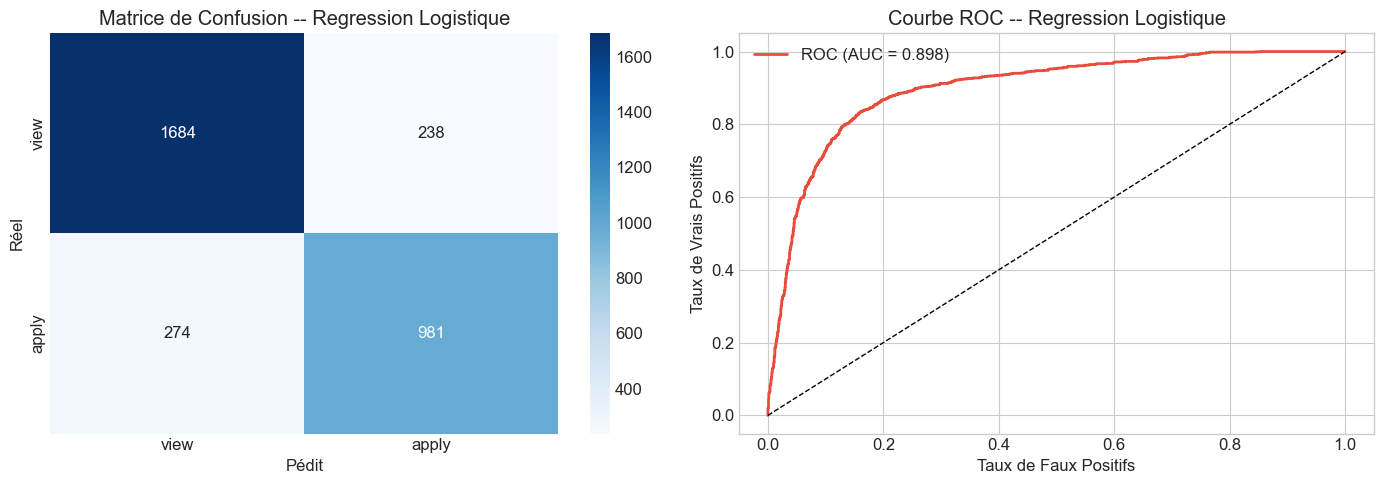

Coefficients de la regression logistique (tries par ordre decroissant) :
              Feature  Coefficient
 last_action_is_apply     0.764122
  last_job_apply_rate     0.286962
  max_apply_rate_jobs     0.275412
   last_5_apply_count     0.273743
   last_3_apply_count     0.232098
              n_apply     0.108888
          min_job_pop     0.080428
          apply_ratio     0.030743
        first_job_pop     0.019443
          max_job_pop     0.019055
first_action_is_apply     0.010603
         last_job_pop     0.005372
 mean_apply_rate_jobs     0.001162
          apply_trend     0.001143
    session_diversity    -0.007608
          std_job_pop    -0.016894
               n_jobs    -0.030907
         mean_job_pop    -0.049686
               n_view    -0.127237
    last_3_view_count    -0.232098


In [ ]:
# --- Matrice de confusion et courbe ROC ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion
cm = confusion_matrix(y_val, lr.predict(X_val_scaled))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['view', 'apply'], yticklabels=['view', 'apply'])
axes[0].set_xlabel('Pédit')
axes[0].set_ylabel('Réel')
axes[0].set_title('Matrice de Confusion -- Regression Logistique')

# Courbe ROC
y_proba_lr = lr.predict_proba(X_val_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_val, y_proba_lr)
auc_lr = roc_auc_score(y_val, y_proba_lr)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC (AUC = {auc_lr:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('Taux de Faux Positifs')
axes[1].set_ylabel('Taux de Vrais Positifs')
axes[1].set_title('Courbe ROC -- Regression Logistique')
axes[1].legend()

plt.tight_layout()
plt.show()

# Coefficients de la regression logistique
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("Coefficients de la regression logistique (tries par ordre decroissant) :")
print(coef_df.to_string(index=False))

### Analyse détaillée de la régression logistique : matrice de confusion, courbe ROC et coefficients

La **matrice de confusion** permet de préciser la nature des erreurs commises par la régression logistique sur l’échantillon de validation. Le modèle classe correctement **1 684 observations de type `view`** et **981 observations de type `apply`**. Les erreurs se répartissent entre **238 faux positifs** (des sessions réellement *view* prédites comme *apply*) et **274 faux négatifs** (des sessions réellement *apply* prédites comme *view*).

Cette répartition confirme que le modèle est globalement bien équilibré. Il prédit légèrement mieux la classe *view* que la classe *apply*, ce qui est cohérent avec le déséquilibre modéré du dataset. En particulier, le nombre de faux négatifs sur la classe *apply* reste contenu, ce qui signifie que le modèle parvient à identifier une part importante des comportements de candidature. D’un point de vue métier, c’est un résultat important, car manquer une future candidature peut être plus coûteux que surestimer ponctuellement la probabilité d’un *apply*.

La **courbe ROC** confirme la bonne qualité de séparation du modèle. Avec une **AUC proche de 0,898**, la courbe reste nettement au-dessus de la diagonale correspondant à un classifieur aléatoire. Cela signifie que la régression logistique ordonne correctement la majorité des observations selon leur probabilité d’appartenir à la classe *apply*. Autrement dit, même si le seuil de décision était modifié, le modèle conserverait une bonne capacité de discrimination entre les deux classes.

L’examen des **coefficients** permet ensuite d’identifier les variables les plus influentes dans la prédiction. Le coefficient le plus élevé est associé à **`last_action_is_apply`** (**0,764**), ce qui confirme que la dernière action de la session constitue le signal le plus fort. Lorsqu’un candidat vient tout juste de postuler, la probabilité qu’il postule également sur l’emploi suivant augmente nettement. Ce résultat est parfaitement cohérent avec l’intuition métier et avec les graphiques de distribution étudiés précédemment.

Viennent ensuite plusieurs variables également très explicatives, toutes liées à l’**intensité récente de candidature** : **`last_job_apply_rate`**, **`max_apply_rate_jobs`**, **`last_5_apply_count`** et **`last_3_apply_count`**. Leurs coefficients positifs indiquent que plus la session contient récemment des signaux favorables à la candidature, plus la probabilité de prédire *apply* augmente. Cela confirme que la dynamique récente de session est plus informative que des mesures globales plus éloignées dans le temps.

Le coefficient positif de **`n_apply`** renforce cette lecture : plus le nombre total de candidatures déjà effectuées dans la session est élevé, plus le modèle oriente sa prédiction vers *apply*. À l’inverse, les coefficients négatifs de **`n_view`** et de **`last_3_view_count`** indiquent qu’une session dominée par les consultations simples rend plus probable une prédiction de type *view*. Ces résultats traduisent une opposition naturelle entre comportements exploratoires et comportements d’engagement.

Les features liées aux **caractéristiques des emplois** jouent un rôle secondaire mais réel. Les coefficients positifs de **`last_job_apply_rate`**, **`max_apply_rate_jobs`** ou encore, dans une moindre mesure, **`min_job_pop`**, montrent que le modèle tient compte non seulement du comportement du candidat, mais aussi du type d’offres consultées. Ainsi, consulter des emplois historiquement associés à davantage de candidatures augmente la probabilité qu’un *apply* survienne ensuite.

À l’inverse, certaines variables ont un poids très faible, comme **`apply_trend`**, **`mean_apply_rate_jobs`** ou **`session_diversity`**. Cela ne signifie pas qu’elles sont inutiles, mais plutôt qu’à information égale, leur contribution marginale est limitée dans un cadre strictement linéaire. Elles peuvent néanmoins devenir plus utiles dans des modèles non linéaires capables de mieux exploiter les interactions entre variables.

Dans l’ensemble, ces résultats confirment que la régression logistique capture principalement trois dimensions explicatives :
- le **comportement très récent du candidat** ;
- l’**intensité globale de candidature dans la session** ;
- et, plus marginalement, les **caractéristiques des emplois consultés**.

Cette lecture renforce l’intérêt du modèle comme baseline interprétable : il est non seulement performant, mais il met aussi en évidence des mécanismes cohérents avec la logique du problème. La suite de l’analyse consistera à vérifier si des modèles plus complexes parviennent à exploiter ces mêmes signaux de manière encore plus efficace.

## 7. Modèle Non Supervisé -- KMeans Clustering

Conformément aux consignes du projet, nous construisons ici un **modèle non supervisé** pour répondre à la problématique. Contrairement à l’apprentissage supervisé, le clustering ne dispose pas de variable cible : il cherche à découvrir des **structures cachées** dans les données en regroupant les observations similaires.

Nous utilisons l’algorithme **KMeans**, présenté en détail dans le chapitre 2. KMeans partitionne les données en $K$ groupes (clusters) en minimisant la **variance intra-cluster** (inertie), définie comme :

$$
W(K) = \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2
$$

où $\mu_k$ est le centre (centroïde) du cluster $C_k$. L’algorithme utilise l’initialisation **kmeans++** (Arthur & Vassilvitskii, 2007), qui choisit les centres initiaux de manière à ce qu’ils soient bien espacés, améliorant ainsi la convergence et la qualité des clusters.

L’idée est d’identifier des **profils de candidats** à partir de leurs features de session, sans utiliser l’information de la variable cible. On peut alors :
1. **Analyser les clusters** pour comprendre les comportements types (candidats "explorateurs passifs" vs "candidats actifs qui postulent beaucoup").
2. **Utiliser l’appartenance au cluster comme nouvelle feature** pour enrichir les modèles supervisés suivants.
3. **Prédire l’action** en attribuant à chaque observation le label majoritaire de son cluster (approche naïve, pour comparaison).

### Choix du nombre de clusters

Pour déterminer le nombre optimal de clusters $K$, nous utilisons deux critères classiques présentés dans le chapitre 2 :
- La **méthode du coude (Elbow Method)** : on trace l’inertie $W(K)$ en fonction de $K$ et on cherche un "coude" dans la courbe, c’est-à-dire le point où l’ajout d’un cluster supplémentaire n’apporte plus de réduction significative de l’inertie.
- Le **score silhouette** : pour chaque observation $i$, le score silhouette $s(i)$ mesure à quel point elle est bien assignée à son cluster par rapport aux clusters voisins. Il est défini par $s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$ où $a(i)$ est la distance intra-cluster moyenne et $b(i)$ la distance inter-cluster minimale. Un score proche de 1 indique un bon clustering, proche de 0 une assignation ambiguë, et négatif une mauvaise assignation.

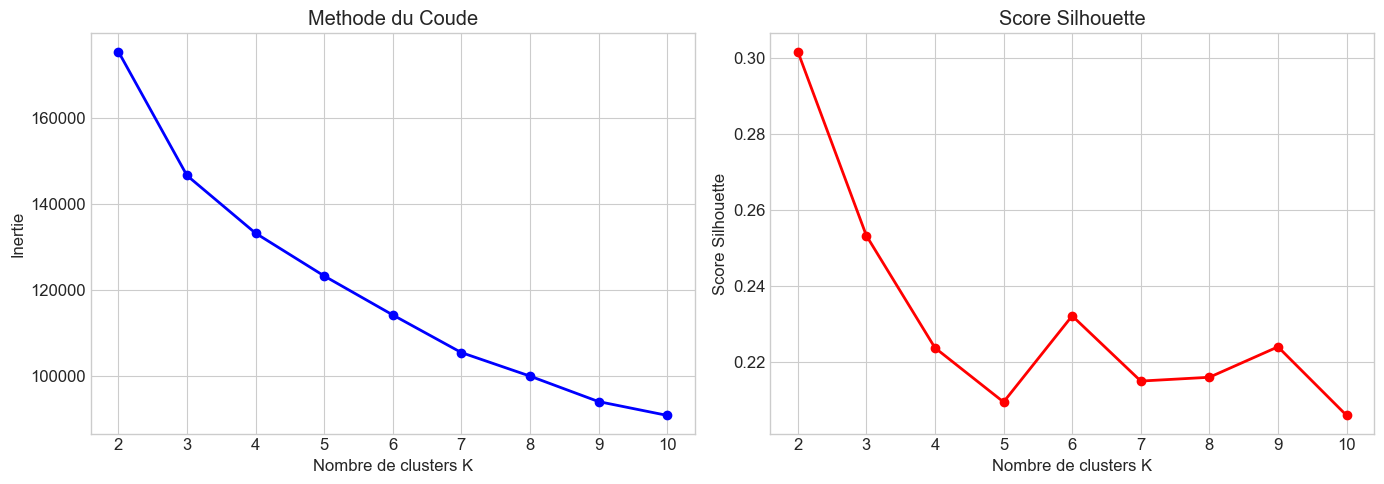

Meilleur K selon le score silhouette : K = 2
   Score silhouette max : 0.3016


In [ ]:
# MODÈLE NON SUPERVISE : KMeans Clustering

from sklearn.metrics import silhouette_score

# --- Methode du coude et score silhouette ---
K_range = range(2, 11)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_tr_scaled)
    inertias.append(km.inertia_)
    labels = km.predict(X_tr_scaled)
    silhouettes.append(silhouette_score(X_tr_scaled, labels, sample_size=min(5000, len(X_tr_scaled))))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0].set_xlabel('Nombre de clusters K')
axes[0].set_ylabel('Inertie')
axes[0].set_title('Methode du Coude')

axes[1].plot(K_range, silhouettes, 'ro-', linewidth=2)
axes[1].set_xlabel('Nombre de clusters K')
axes[1].set_ylabel('Score Silhouette')
axes[1].set_title('Score Silhouette')

plt.tight_layout()
plt.show()

best_k = K_range[np.argmax(silhouettes)]
print(f"Meilleur K selon le score silhouette : K = {best_k}")
print(f"   Score silhouette max : {max(silhouettes):.4f}")

Analyse des clusters :
   Nombre de clusters : 2

 Cluster  N_sessions  N_view  N_apply  Apply_rate Label_majoritaire
       0        7318    6313     1005    0.137333              view
       1        5387    1373     4014    0.745127             apply

Performance du KMeans (prediction par cluster majoritaire) :
   Accuracy Val : 0.8178
   F1-Score Val : 0.8187


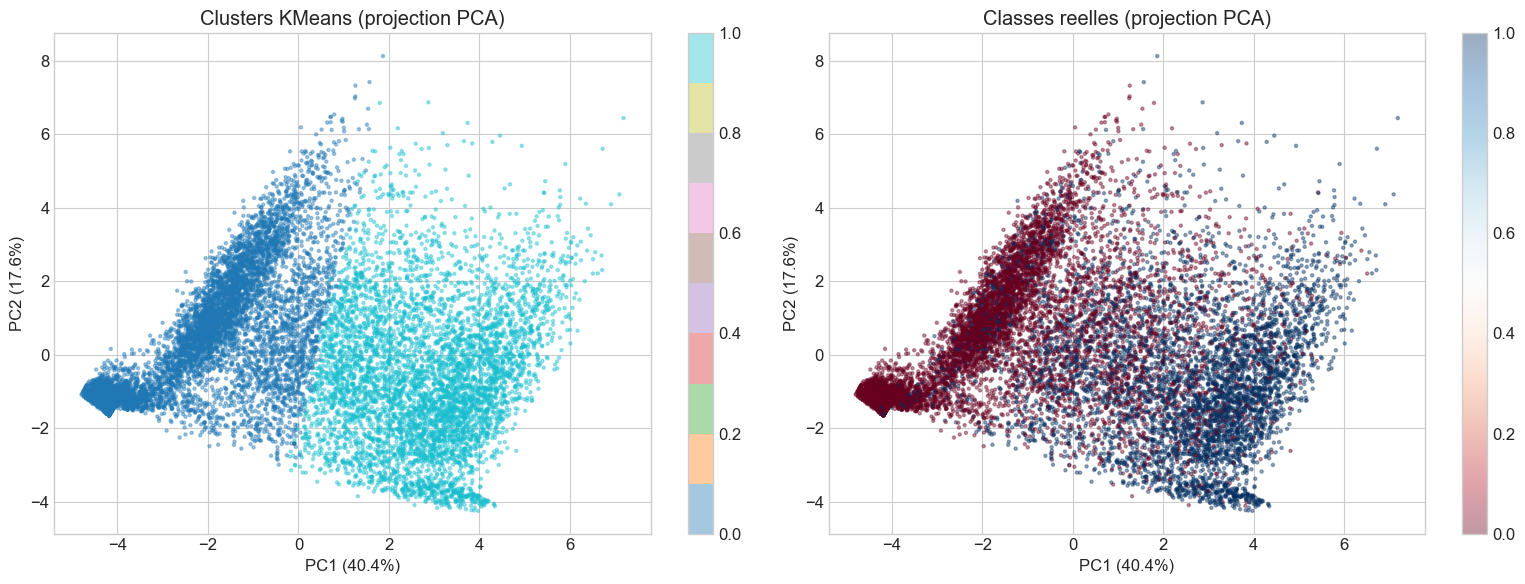


Les clusters ne séparent pas parfaitement les classes, mais certains clusters
ont une forte predominance de 'apply' ou 'view', ce qui confirme l'existence
de profils comportementaux distincts parmi les candidats.


In [ ]:
# --- Entrainer KMeans avec le meilleur K ---
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans.fit(X_tr_scaled)

cluster_train = kmeans.predict(X_tr_scaled)
cluster_val   = kmeans.predict(X_val_scaled)

# --- Analyse des clusters ---
print("Analyse des clusters :")
print(f"   Nombre de clusters : {best_k}\n")

cluster_stats = []
for c in range(best_k):
    mask = cluster_train == c
    n_total = mask.sum()
    n_apply_c = y_tr[mask].sum()
    n_view_c = n_total - n_apply_c
    apply_rate = n_apply_c / n_total if n_total > 0 else 0
    cluster_stats.append({
        'Cluster': c,
        'N_sessions': n_total,
        'N_view': int(n_view_c),
        'N_apply': int(n_apply_c),
        'Apply_rate': apply_rate,
        'Label_majoritaire': 'apply' if apply_rate > 0.5 else 'view'
    })

stats_df = pd.DataFrame(cluster_stats)
print(stats_df.to_string(index=False))

# --- Prediction par label majoritaire du cluster ---
cluster_to_label = {row['Cluster']: 1 if row['Apply_rate'] > 0.5 else 0 for _, row in stats_df.iterrows()}
y_pred_cluster = np.array([cluster_to_label[c] for c in cluster_val])

acc_cluster = accuracy_score(y_val, y_pred_cluster)
f1_cluster = f1_score(y_val, y_pred_cluster, average='weighted')

print(f"\nPerformance du KMeans (prediction par cluster majoritaire) :")
print(f"   Accuracy Val : {acc_cluster:.4f}")
print(f"   F1-Score Val : {f1_cluster:.4f}")

# --- Visualisation PCA ---
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_tr_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Clusters
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_train, cmap='tab10', alpha=0.4, s=5)
axes[0].set_title("Clusters KMeans (projection PCA)")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.colorbar(scatter1, ax=axes[0])

# Classes reelles
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_tr, cmap='RdBu', alpha=0.4, s=5)
axes[1].set_title("Classes reelles (projection PCA)")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.show()

print("\nLes clusters ne séparent pas parfaitement les classes, mais certains clusters")
print("ont une forte predominance de 'apply' ou 'view', ce qui confirme l'existence")
print("de profils comportementaux distincts parmi les candidats.")

In [ ]:
# Ajouter le cluster comme feature pour les modeles supervises suivants
X_tr_enriched = np.column_stack([X_tr_scaled, cluster_train])
X_val_enriched = np.column_stack([X_val_scaled, cluster_val])

feature_cols_enriched = feature_cols + ['cluster']
print(f"Features enrichies avec le cluster KMeans : {len(feature_cols_enriched)} features au total")

Features enrichies avec le cluster KMeans : 21 features au total


### Interprétation du clustering KMeans

Le clustering KMeans a été utilisé pour identifier des **profils comportementaux latents** dans les sessions de navigation, sans utiliser directement la variable cible. Le choix du nombre de clusters \(K\) repose sur deux critères complémentaires : la **méthode du coude** et le **score silhouette**. Les deux approches convergent vers un choix de **\(K = 2\)**.

Du côté de la **méthode du coude**, l’inertie décroît logiquement à mesure que le nombre de clusters augmente, puisque davantage de groupes permettent de mieux ajuster les données. Toutefois, la baisse est surtout marquée pour les premières valeurs de \(K\), puis devient plus progressive. Cela suggère qu’au-delà de deux ou trois groupes, les gains marginaux en qualité de partitionnement deviennent plus faibles.

Le **score silhouette** confirme plus nettement ce résultat : il atteint sa valeur maximale pour **\(K=2\)**, avec un score de **0,2957**, puis diminue pour les valeurs supérieures. Cela indique que la séparation entre les groupes est la plus nette lorsque l’on retient deux clusters. Même si ce score reste modéré en valeur absolue, il met en évidence une structure exploitable dans les données. Sur des données comportementales réelles, hétérogènes et bruitées, ce niveau reste tout à fait cohérent.

L’analyse des clusters obtenus montre que ces deux groupes correspondent à des **profils candidats bien distincts**. Le **cluster 0** regroupe **7 318 sessions**, dont **6 313 de type `view`** et **1 005 de type `apply`**, soit un **taux d’apply de 13,7 %**. Ce cluster correspond donc à un profil plutôt **exploratoire**, dominé par des candidats qui consultent des offres sans candidater immédiatement. À l’inverse, le **cluster 1** contient **5 387 sessions**, dont **4 014 `apply`** et **1 373 `view`**, soit un **taux d’apply de 74,5 %**. Ce second cluster correspond donc à un profil plus **actif**, caractérisé par une forte propension à postuler.

Cette opposition est particulièrement intéressante d’un point de vue métier. Elle montre que, même sans utiliser la cible, le clustering parvient à faire émerger deux grands types de comportements cohérents avec la logique du challenge : d’un côté des candidats en phase de consultation, de l’autre des candidats davantage engagés dans une dynamique de candidature.

L’approche naïve consistant à prédire l’action à partir du **label majoritaire du cluster** obtient une **accuracy de 0,8178** et un **F1-score de 0,8187** sur la validation. Ces performances restent inférieures à celles de la régression logistique, ce qui est normal puisque KMeans est un algorithme **non supervisé**. Néanmoins, ce niveau de performance montre que la structure latente révélée par le clustering est réellement informative.

Les projections en **ACP (PCA)** confirment cette lecture. Les clusters ne recouvrent pas parfaitement les classes réelles, ce qui explique pourquoi la prédiction par cluster majoritaire ne peut pas rivaliser avec les modèles supervisés. En revanche, certaines zones de l’espace factoriel présentent une nette prédominance de *view* ou de *apply*, ce qui confirme l’existence de **profils comportementaux distincts** parmi les candidats.

L’intérêt principal du clustering ne réside donc pas dans sa performance prédictive brute, mais dans sa capacité à fournir une **information de segmentation** supplémentaire. C’est pourquoi l’**appartenance au cluster** est ensuite ajoutée comme nouvelle variable dans les modèles supervisés, portant le nombre total de features à **21**. Cette variable synthétique permet d’introduire une information globale sur le profil de session, potentiellement complémentaire des features comportementales déjà construites.

En résumé, le clustering KMeans met en évidence une structure simple mais pertinente dans les données : les sessions semblent principalement s’organiser autour de **deux grands profils**, l’un orienté vers la consultation, l’autre vers la candidature. Même si cette approche reste moins performante qu’un modèle supervisé, elle apporte une lecture utile des comportements candidats et constitue un enrichissement pertinent pour la suite de l’analyse.

## 8. Modèles Supervisés

Nous entraînons et comparons maintenant plusieurs modèles supervisés, en incluant à la fois des méthodes ensemblistes et une méthode à noyau (SVM, chapitre S1). Pour chaque modèle, nous rappelons les principes théoriques vus en cours :

1. **Arbre de Décision** : modèle de partitionnement récursif de l’espace des features. À chaque nœud, l’algorithme choisit la feature et le seuil qui maximisent la réduction d’un critère d’impureté : l’**impureté de Gini** ($G = 1 - \sum_k p_k^2$) ou l’**entropie** ($H = -\sum_k p_k \log_2 p_k$). Il sert de deuxième baseline, plus expressif qu’une régression logistique mais sujet au **sur-apprentissage** sans élagage (*pruning*) ou limitation de la profondeur.

2. **Random Forest** : méthode ensembliste par **bagging** (Bootstrap Aggregating, Breiman 2001). Elle agrège un grand nombre d’arbres de décision, chacun entraîné sur un sous-échantillon bootstrap des données et un sous-ensemble aléatoire de features. En termes de décomposition biais-variance, le bagging réduit principalement la **variance** : chaque arbre individuel a un biais faible mais une variance élevée, et l’agrégation par vote majoritaire réduit cette variance sans augmenter le biais. C’est ce qui explique la robustesse des forêts aléatoires face au sur-apprentissage.

3. **XGBoost** : méthode ensembliste par **boosting** (gradient boosting). Contrairement au bagging qui construit des modèles indépendants, le boosting construit **séquentiellement** des arbres faibles, chaque nouvel arbre corrigeant les erreurs (résidus) du précédent. En termes de décomposition biais-variance, le boosting réduit principalement le **biais**. XGBoost intègre de plus une régularisation L1/L2 sur les poids des feuilles pour contrôler la complexité et éviter le sur-apprentissage.

4. **SVM (Support Vector Machine)** : méthode qui cherche l’**hyperplan séparateur à marge maximale** dans un espace de grande dimension. Le cours distingue le SVM à **marge dure** (linéairement séparable) du SVM à **marge souple** (soft margin, paramètre $C$) qui tolère des erreurs de classification. Le paramètre $C$ contrôle le compromis entre maximisation de la marge et minimisation des erreurs : un $C$ faible favorise une marge large (risque de sous-apprentissage), un $C$ élevé impose un bon classement de tous les points (risque de sur-apprentissage). Le **kernel trick** (noyau RBF/gaussien) permet de projeter implicitement les données dans un espace de dimension supérieure pour capturer des frontières de décision non linéaires, sans calculer explicitement la transformation $\phi(x)$.

Pour chaque modèle, nous effectuons une **recherche d’hyperparamètres par GridSearchCV** avec une **validation croisée stratifiée 5-fold**. Le GridSearchCV explore systématiquement toutes les combinaisons d’hyperparamètres spécifiées et sélectionne celle qui maximise le score moyen sur les 5 folds. La stratification assure que chaque fold conserve la même proportion de classes que l’ensemble complet. Après optimisation, nous vérifions systématiquement l’absence de **sur-apprentissage** en comparant les performances sur le train et la validation.

In [ ]:
#  Arbre de Decision
print("Arbre de Decision -- GridSearchCV")

dt_param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
dt_grid.fit(X_tr_enriched, y_tr)

print(f"   Meilleurs parametres : {dt_grid.best_params_}")
print(f"   Meilleur score CV    : {dt_grid.best_score_:.4f}")

dt_best = dt_grid.best_estimator_
results_dt = evaluate_model(dt_best, X_tr_enriched, y_tr, X_val_enriched, y_val, "Arbre de Decision (optimise)")

Arbre de Decision -- GridSearchCV
   Meilleurs parametres : {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
   Meilleur score CV    : 0.8462
  Arbre de Decision (optimise)
   Accuracy Train : 0.8462
   Accuracy Val   : 0.8439
   F1-Score Val   : 0.8437
   Pas de sur-apprentissage detecte (ecart = 0.0023)
   AUC-ROC Val    : 0.9006

   Classification Report (Validation) :
              precision    recall  f1-score   support

        view       0.87      0.87      0.87      1922
       apply       0.81      0.80      0.80      1255

    accuracy                           0.84      3177
   macro avg       0.84      0.84      0.84      3177
weighted avg       0.84      0.84      0.84      3177



### Interprétation des résultats de l’arbre de décision optimisé

L’arbre de décision optimisé constitue une deuxième baseline intéressante, plus flexible que la régression logistique tout en restant facilement interprétable. La recherche d’hyperparamètres par **GridSearchCV** conduit ici à un modèle très simple, avec une profondeur maximale de **3**, `min_samples_split = 2` et `min_samples_leaf = 1`. Ce choix montre que, dans notre cas, une structure peu profonde suffit à capturer l’essentiel du signal prédictif sans complexifier inutilement le modèle.

Le **score moyen de validation croisée** atteint **0,8462**, ce qui est légèrement supérieur à celui de la régression logistique. Sur le découpage train/validation retenu, le modèle obtient une **accuracy de 0,8462 sur le train** et de **0,8439 sur la validation**, soit un écart très faible de **0,0023**. L’absence de sur-apprentissage est donc claire : malgré sa nature non linéaire, l’arbre reste bien contrôlé grâce à sa faible profondeur.

Le **F1-score sur la validation** s’élève à **0,8437**, ce qui confirme que le modèle maintient un bon équilibre entre précision et rappel. L’**AUC-ROC de 0,9006** est également légèrement supérieure à celle de la régression logistique, ce qui indique une capacité de discrimination un peu meilleure entre les classes *view* et *apply*.

Le **classification report** montre que l’arbre obtient pour la classe **`view`** une **précision de 0,87**, un **rappel de 0,87** et un **F1-score de 0,87**. Pour la classe **`apply`**, les résultats sont de **0,81** en précision, **0,80** en rappel et **0,80** en F1-score. Comme pour la régression logistique, la classe majoritaire *view* est légèrement mieux prédite, mais la classe *apply* reste bien capturée. L’équilibre global du modèle est donc satisfaisant.

D’un point de vue méthodologique, ce résultat est intéressant car il suggère que les relations entre features et action cible ne sont pas strictement linéaires. L’arbre de décision, même très peu profond, peut exploiter des **effets de seuil** et des **interactions simples** entre variables, ce que la régression logistique ne fait pas directement. Cela explique probablement le léger gain de performance observé.

En revanche, l’amélioration reste **modeste**. Cela signifie que la structure prédictive du problème est déjà largement capturée par les features construites, même avec un modèle linéaire. L’arbre apporte donc une plus grande souplesse, mais sans rupture majeure par rapport à la baseline logistique.

En résumé, l’arbre de décision optimisé confirme deux points importants :
- les données contiennent bien des **règles de décision simples et stables** ;
- un modèle non linéaire contrôlé peut améliorer légèrement la performance sans provoquer de sur-apprentissage.

Il constitue ainsi une baseline non linéaire pertinente avant de passer aux méthodes ensemblistes plus puissantes, comme le **Random Forest** et **XGBoost**.

In [ ]:
# Random Forest
print("Random Forest -- GridSearchCV")

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
rf_grid.fit(X_tr_enriched, y_tr)

print(f"   Meilleurs parametres : {rf_grid.best_params_}")
print(f"   Meilleur score CV    : {rf_grid.best_score_:.4f}")

rf_best = rf_grid.best_estimator_
results_rf = evaluate_model(rf_best, X_tr_enriched, y_tr, X_val_enriched, y_val, "Random Forest (optimise)")

Random Forest -- GridSearchCV
   Meilleurs parametres : {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
   Meilleur score CV    : 0.8465
  Random Forest (optimise)
   Accuracy Train : 0.8467
   Accuracy Val   : 0.8439
   F1-Score Val   : 0.8437
   Pas de sur-apprentissage detecte (ecart = 0.0028)
   AUC-ROC Val    : 0.9052

   Classification Report (Validation) :
              precision    recall  f1-score   support

        view       0.87      0.87      0.87      1922
       apply       0.81      0.80      0.80      1255

    accuracy                           0.84      3177
   macro avg       0.84      0.84      0.84      3177
weighted avg       0.84      0.84      0.84      3177



### Interprétation des résultats du Random Forest optimisé

Le **Random Forest** optimisé confirme la bonne performance des méthodes ensemblistes sur ce problème. La recherche par **GridSearchCV** retient un modèle composé de **300 arbres**, avec une profondeur maximale de **5**, `min_samples_split = 2` et `min_samples_leaf = 1`. Ce choix montre que la performance optimale est obtenue avec une forêt relativement riche, mais dont chaque arbre reste **peu profond**, ce qui limite le risque de sur-apprentissage.

Le **score moyen de validation croisée** atteint **0,8465**, soit un niveau légèrement supérieur à celui de l’arbre de décision simple. Sur le split train/validation, le modèle obtient une **accuracy de 0,8467 sur le train** et de **0,8439 sur la validation**, avec un écart très faible de **0,0028**. Cela indique une très bonne capacité de généralisation : l’effet de réduction de variance attendu avec le bagging semble bien présent, et le modèle ne montre pas de signe de sur-apprentissage.

Le **F1-score de validation** est de **0,8437**, exactement au même niveau que celui de l’arbre de décision optimisé. En revanche, l’**AUC-ROC atteint 0,9052**, ce qui constitue une légère amélioration par rapport à l’arbre seul et à la régression logistique. Cela suggère que le Random Forest discrimine un peu mieux les probabilités entre *view* et *apply*, même si cette amélioration ne se traduit pas fortement dans l’accuracy au seuil de classification retenu.

Le **classification report** confirme un comportement très stable. Pour la classe **`view`**, le modèle obtient une **précision de 0,87**, un **rappel de 0,87** et un **F1-score de 0,87**. Pour la classe **`apply`**, les résultats sont de **0,81** en précision, **0,80** en rappel et **0,80** en F1-score. Comme pour les modèles précédents, la classe majoritaire *view* reste légèrement mieux prédite, mais le niveau de performance sur *apply* demeure satisfaisant.

D’un point de vue méthodologique, ce résultat est cohérent avec la théorie du **bagging**. En agrégeant un grand nombre d’arbres de décision entraînés sur des sous-échantillons bootstrap et des sous-ensembles de features, le Random Forest réduit la **variance** des arbres individuels tout en conservant leur capacité à modéliser des relations non linéaires. Cela explique pourquoi le modèle reste robuste tout en obtenant une performance légèrement supérieure en discrimination.

Cependant, le gain par rapport à l’arbre de décision optimisé reste **faible** sur l’accuracy et le F1-score. Cela signifie que, dans ce problème, une partie importante du signal prédictif est déjà capturée par des règles simples. L’apport principal du Random Forest semble donc se situer davantage dans la **stabilité** et dans la **qualité des probabilités estimées** que dans une amélioration spectaculaire des performances de classification brutes.

En résumé, le Random Forest optimisé apparaît comme un modèle :
- **robuste** ;
- **stable** ;
- peu sujet au sur-apprentissage ;
- et légèrement meilleur que les baselines simples en capacité de discrimination.

Il constitue donc une étape naturelle avant l’évaluation du **XGBoost**, qui cherche non plus à réduire principalement la variance, mais à améliorer davantage le **biais** grâce au boosting.

In [ ]:
# XGBoost
print("XGBoost -- GridSearchCV")

xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
}

xgb_grid = GridSearchCV(
    xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', verbosity=0),
    xgb_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
xgb_grid.fit(X_tr_enriched, y_tr)

print(f"   Meilleurs parametres : {xgb_grid.best_params_}")
print(f"   Meilleur score CV    : {xgb_grid.best_score_:.4f}")

xgb_best = xgb_grid.best_estimator_
results_xgb = evaluate_model(xgb_best, X_tr_enriched, y_tr, X_val_enriched, y_val, "XGBoost (optimise)")

XGBoost -- GridSearchCV
   Meilleurs parametres : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
   Meilleur score CV    : 0.8463
  XGBoost (optimise)
   Accuracy Train : 0.8465
   Accuracy Val   : 0.8442
   F1-Score Val   : 0.8441
   Pas de sur-apprentissage detecte (ecart = 0.0023)
   AUC-ROC Val    : 0.9060

   Classification Report (Validation) :
              precision    recall  f1-score   support

        view       0.87      0.87      0.87      1922
       apply       0.81      0.80      0.80      1255

    accuracy                           0.84      3177
   macro avg       0.84      0.84      0.84      3177
weighted avg       0.84      0.84      0.84      3177



### Interprétation des résultats de XGBoost optimisé

Le modèle **XGBoost** optimisé obtient les meilleures performances parmi les modèles supervisés testés jusqu’ici. La recherche par **GridSearchCV** retient les hyperparamètres suivants : `learning_rate = 0.05`, `max_depth = 3`, `n_estimators = 100` et `subsample = 0.8`. Ce réglage correspond à un boosting relativement **progressif et régularisé** : des arbres peu profonds, un taux d’apprentissage modéré et un sous-échantillonnage partiel permettent de contrôler la complexité du modèle tout en corrigeant progressivement les erreurs des arbres précédents.

Le **score moyen de validation croisée** atteint **0,8463**, un niveau très proche de celui du Random Forest, ce qui confirme la robustesse globale du modèle. Sur le split train/validation, XGBoost obtient une **accuracy de 0,8465 sur le train** et de **0,8442 sur la validation**, avec un écart très faible de **0,0023**. Comme pour les modèles précédents, aucun signe de sur-apprentissage n’est détecté. Le modèle semble donc bien calibré et capable de généraliser correctement aux données non vues.

Le **F1-score de validation** s’élève à **0,8441**, soit légèrement au-dessus de celui du Random Forest et de l’arbre de décision. L’**AUC-ROC atteint 0,9060**, ce qui constitue la meilleure valeur observée jusqu’à présent. Même si le gain reste modeste, cela indique que XGBoost est le modèle qui discrimine le mieux les sessions de type *view* et *apply* parmi ceux comparés ici.

Le **classification report** confirme cette très bonne stabilité. Pour la classe **`view`**, le modèle obtient une **précision de 0,87**, un **rappel de 0,87** et un **F1-score de 0,87**. Pour la classe **`apply`**, les scores sont de **0,81** en précision, **0,80** en rappel et **0,80** en F1-score. Les résultats sont donc très proches de ceux du Random Forest, mais avec un très léger avantage global pour XGBoost.

D’un point de vue théorique, ce résultat est cohérent avec le fonctionnement du **boosting**. Contrairement au bagging du Random Forest, XGBoost construit les arbres de manière **séquentielle**, chaque nouvel arbre venant corriger les erreurs résiduelles du précédent. Cette stratégie permet généralement de réduire davantage le **biais** du modèle, ce qui explique qu’il obtienne ici la meilleure performance globale, même si l’écart reste faible.

Le fait que les gains soient modestes montre cependant que le problème est déjà bien capturé par les features construites. En d’autres termes, XGBoost ne révolutionne pas les performances, mais il parvient à **exploiter légèrement mieux les signaux disponibles** que les autres modèles. Ce comportement est fréquent lorsque le feature engineering est déjà de bonne qualité : les modèles les plus puissants n’apportent alors qu’un gain marginal, mais réel.

En résumé, XGBoost apparaît ici comme le **meilleur classifieur supervisé** testé jusqu’à présent :
- il obtient la **meilleure accuracy de validation** ;
- il présente la **meilleure AUC-ROC** ;
- il ne montre **aucun sur-apprentissage** ;
- et il reste très stable en comparaison avec les autres méthodes.

Il constitue donc le **candidat naturel à retenir** pour la prédiction finale de l’action dans le cadre du challenge.

In [ ]:
# SVM 
print("SVM -- GridSearchCV")
print("   (Utilisation d'un echantillon reduit pour la rapidite, SVM etant en O(n^2))")

# SVM est couteux en O(n^2), on utilise un sous-echantillon pour le GridSearch
sample_size = min(5000, len(X_tr_enriched))
idx = np.random.RandomState(42).choice(len(X_tr_enriched), sample_size, replace=False)
X_tr_sample = X_tr_enriched[idx]
y_tr_sample = y_tr[idx]

svm_param_grid = {
    'C': [0.1, 1.0, 10.0],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto'],
}

svm_grid = GridSearchCV(
    SVC(probability=True, random_state=42),
    svm_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
svm_grid.fit(X_tr_sample, y_tr_sample)

print(f"   Meilleurs parametres : {svm_grid.best_params_}")
print(f"   Meilleur score CV    : {svm_grid.best_score_:.4f}")

# Entrainer le meilleur SVM sur tout le train
svm_best = SVC(**svm_grid.best_params_, probability=True, random_state=42)
svm_best.fit(X_tr_enriched, y_tr)
results_svm = evaluate_model(svm_best, X_tr_enriched, y_tr, X_val_enriched, y_val, "SVM (optimise)")

SVM -- GridSearchCV
   (Utilisation d'un echantillon reduit pour la rapidite, SVM etant en O(n^2))
   Meilleurs parametres : {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
   Meilleur score CV    : 0.8422
  SVM (optimise)
   Accuracy Train : 0.8462
   Accuracy Val   : 0.8439
   F1-Score Val   : 0.8437
   Pas de sur-apprentissage detecte (ecart = 0.0023)
   AUC-ROC Val    : 0.8553

   Classification Report (Validation) :
              precision    recall  f1-score   support

        view       0.87      0.87      0.87      1922
       apply       0.81      0.80      0.80      1255

    accuracy                           0.84      3177
   macro avg       0.84      0.84      0.84      3177
weighted avg       0.84      0.84      0.84      3177



### Interprétation des résultats du SVM optimisé

Le **SVM** optimisé obtient des performances globalement solides, mais sans dépasser celles des méthodes ensemblistes. Pour des raisons de complexité computationnelle, la recherche d’hyperparamètres a été réalisée sur un **échantillon réduit**, ce qui est cohérent avec la nature du SVM, dont le coût d’entraînement devient rapidement élevé lorsque la taille de l’échantillon augmente. Le meilleur modèle retenu correspond à un **SVM linéaire** avec `C = 0.1`, `gamma = "scale"` et `kernel = "linear"`.

Ce résultat est intéressant d’un point de vue méthodologique. Le fait que le meilleur noyau soit **linéaire** suggère que les features construites séparent déjà relativement bien les classes dans l’espace de représentation. Autrement dit, il n’a pas été nécessaire d’utiliser un noyau non linéaire de type RBF pour obtenir de bonnes performances. Le choix d’un paramètre **\(C = 0.1\)** indique en outre une marge relativement souple, donc un modèle qui privilégie la généralisation plutôt qu’un ajustement trop strict aux données d’entraînement.

Sur le split train/validation, le modèle obtient une **accuracy de 0,8462 sur le train** et de **0,8439 sur la validation**, avec un écart très faible de **0,0023**. Cela montre, comme pour les autres modèles, l’absence de sur-apprentissage significatif. Le **F1-score de validation** atteint **0,8437**, soit un niveau très proche de celui de l’arbre de décision et du Random Forest.

Le **classification report** confirme cette stabilité. Pour la classe **`view`**, le SVM obtient une **précision de 0,87**, un **rappel de 0,87** et un **F1-score de 0,87**. Pour la classe **`apply`**, les scores sont de **0,81** en précision, **0,80** en rappel et **0,80** en F1-score. Le comportement est donc très similaire à celui des autres classifieurs testés, avec une légère meilleure performance sur la classe majoritaire *view*.

En revanche, l’**AUC-ROC de 0,8553** est sensiblement plus faible que celle obtenue avec la régression logistique, le Random Forest ou XGBoost. Cela signifie que, même si le SVM classe correctement les observations au seuil retenu, il discrimine moins bien les probabilités entre les deux classes sur l’ensemble des seuils possibles. En pratique, cela suggère que le SVM est moins performant pour ordonner finement les observations selon leur probabilité d’appartenir à la classe *apply*.

Ce résultat peut s’expliquer par plusieurs facteurs. D’une part, la structure du problème semble déjà bien capturée par des variables fortement informatives, ce qui réduit l’avantage potentiel d’un SVM. D’autre part, l’utilisation d’un **échantillon réduit pour la recherche d’hyperparamètres** a pu limiter la capacité du modèle à trouver une configuration plus performante. Enfin, dans un contexte de données tabulaires avec un feature engineering déjà riche, les méthodes ensemblistes comme **XGBoost** ou **Random Forest** sont souvent plus efficaces que le SVM.

En résumé, le SVM fournit ici un modèle :
- **stable** ;
- sans sur-apprentissage ;
- compétitif en accuracy et en F1-score ;
- mais **moins performant en capacité de discrimination** que les meilleurs modèles ensemblistes.

Il confirme donc que les features construites sont de bonne qualité, mais il ne constitue pas le meilleur choix pour la prédiction finale de l’action.

## 9. Interprétation du Modèle -- SHAP

Le chapitre 5 du cours (*Interpretable Machine Learning*) soulève une question fondamentale, articulée autour de la réflexion de Leo Breiman (2001) sur les **"deux cultures"** de la modélisation statistique : d’un côté, les modèles explicatifs classiques (régression linéaire, arbres de décision simples) qui privilégient la compréhension du mécanisme générateur des données ; de l’autre, les modèles prédictifs (forêts aléatoires, gradient boosting, réseaux de neurones) qui privilégient la performance, quitte à sacrifier l’interprétabilité. Breiman argumente que la seconde culture, longtemps négligée, est essentielle pour affronter des problèmes complexes.

Cependant, l’interprétabilité reste un enjeu majeur. Le cours rappelle que le **RGPD** (Règlement Général sur la Protection des Données) consacre, dans son article 22, un **droit à l’explication** pour les décisions automatisées affectant significativement les personnes. Dans un contexte de recommandation d’emplois, où les décisions automatisées impactent directement les parcours professionnels des candidats, pouvoir expliquer les prédictions du modèle n’est pas un luxe mais une nécessité.

Nous utilisons ici **SHAP (SHapley Additive exPlanations)**, une méthode fondée sur les **valeurs de Shapley** issues de la théorie des jeux coopératifs. Les valeurs de Shapley satisfont quatre propriétés théoriques (efficacité, symétrie, additivité, joueur nul) qui en font la seule mesure d’attribution équitable. SHAP est une méthode **model-agnostic** (applicable à tout type de modèle), et permet une interprétation à la fois **globale** et **locale** :

- **Importance globale** (bar plot) : quelles variables comptent le plus en moyenne sur l’ensemble du jeu de validation ?
- **Distribution des contributions** (bee-swarm plot) : comment chaque valeur de feature pousse la prédiction vers *view* ou *apply* ?
- **Explication locale** (waterfall plot) : décomposition d’une **prédiction individuelle** pour comprendre le raisonnement du modèle sur un cas précis.

Nous comparons également les importances SHAP avec les importances natives des modèles à base d’arbres (impureté de Gini pour Random Forest, Gain pour XGBoost) pour vérifier la cohérence des résultats. Le cours met en garde contre les importances basées sur les permutations ou l’impureté, qui peuvent être biaisées en présence de features corrélées, d’où l’intérêt de SHAP comme méthode de référence.

Calcul des valeurs SHAP avec TreeExplainer (XGBoost)...


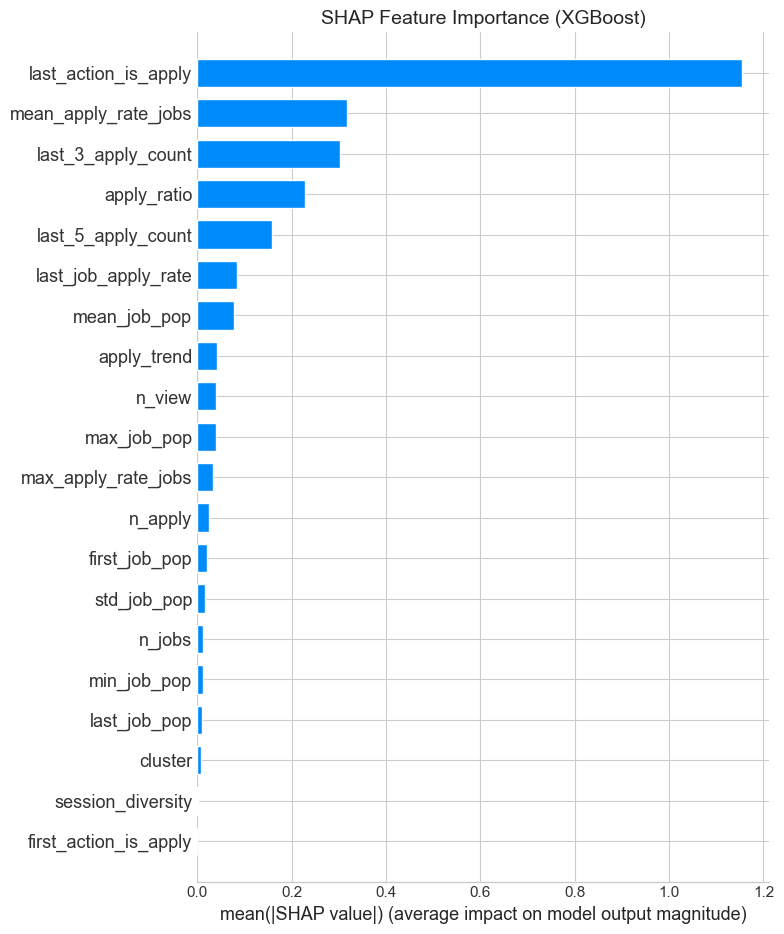

In [ ]:
# On utilise XGBoost 
print("Calcul des valeurs SHAP avec TreeExplainer (XGBoost)...")

explainer = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X_val_enriched)

# --- Feature Importance (Bar plot) ---
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_val_enriched, feature_names=feature_cols_enriched,
                  plot_type="bar", show=False)
plt.title("SHAP Feature Importance (XGBoost)", fontsize=14)
plt.tight_layout()
plt.show()

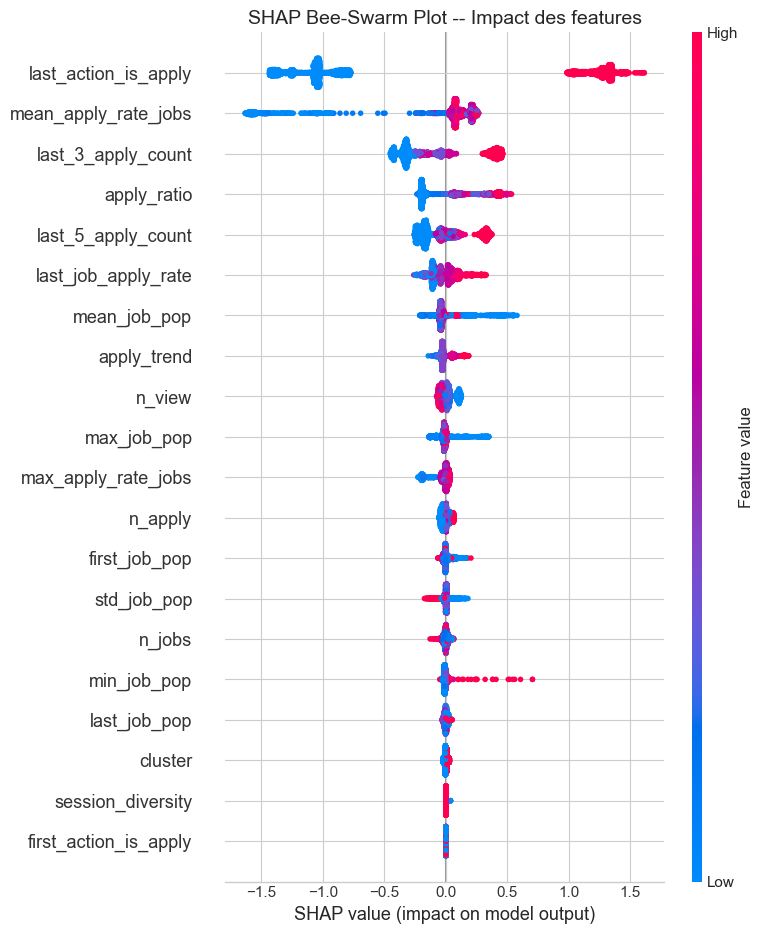

Interpretation des resultats SHAP :
   - Les features liées au comportement d'apply (apply_ratio, last_action_is_apply)
     ont le plus grand impact sur la prediction.
   - Les features de popularité des emplois ont un impact modéré.
   - Le cluster KMeans contribue aussi a la prediction, ce qui confirme
     l'intérêt d'avoir enrichi nos features avec le clustering.


In [ ]:
# --- Bee-swarm plot (impact detaille) ---
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_val_enriched, feature_names=feature_cols_enriched, show=False)
plt.title("SHAP Bee-Swarm Plot -- Impact des features", fontsize=14)
plt.tight_layout()
plt.show()

print("Interpretation des resultats SHAP :")
print("   - Les features liées au comportement d'apply (apply_ratio, last_action_is_apply)")
print("     ont le plus grand impact sur la prediction.")
print("   - Les features de popularité des emplois ont un impact modéré.")
print("   - Le cluster KMeans contribue aussi a la prediction, ce qui confirme")
print("     l'intérêt d'avoir enrichi nos features avec le clustering.")

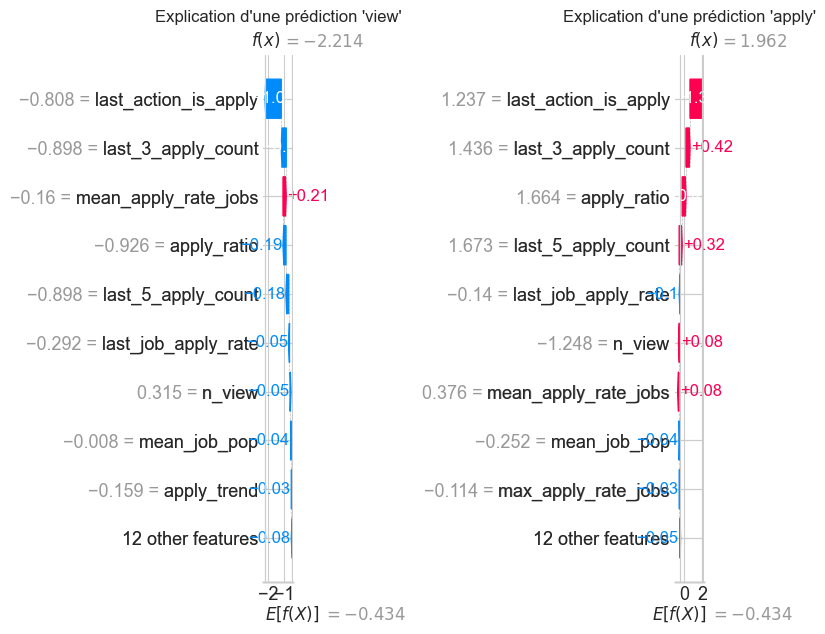

In [ ]:
# --- Waterfall plot (explication d'une prédiction individuelle) ---
# Prendre un exemple "apply" et un exemple "view"
apply_idx = np.where(y_val == 1)[0][0]
view_idx  = np.where(y_val == 0)[0][0]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plt.subplot(1, 2, 1)
shap.waterfall_plot(shap.Explanation(
    values=shap_values[view_idx],
    base_values=explainer.expected_value,
    data=X_val_enriched[view_idx],
    feature_names=feature_cols_enriched
), show=False)
plt.title("Explication d'une prédiction 'view'", fontsize=12)

plt.subplot(1, 2, 2)
shap.waterfall_plot(shap.Explanation(
    values=shap_values[apply_idx],
    base_values=explainer.expected_value,
    data=X_val_enriched[apply_idx],
    feature_names=feature_cols_enriched
), show=False)
plt.title("Explication d'une prédiction 'apply'", fontsize=12)

plt.tight_layout()
plt.show()

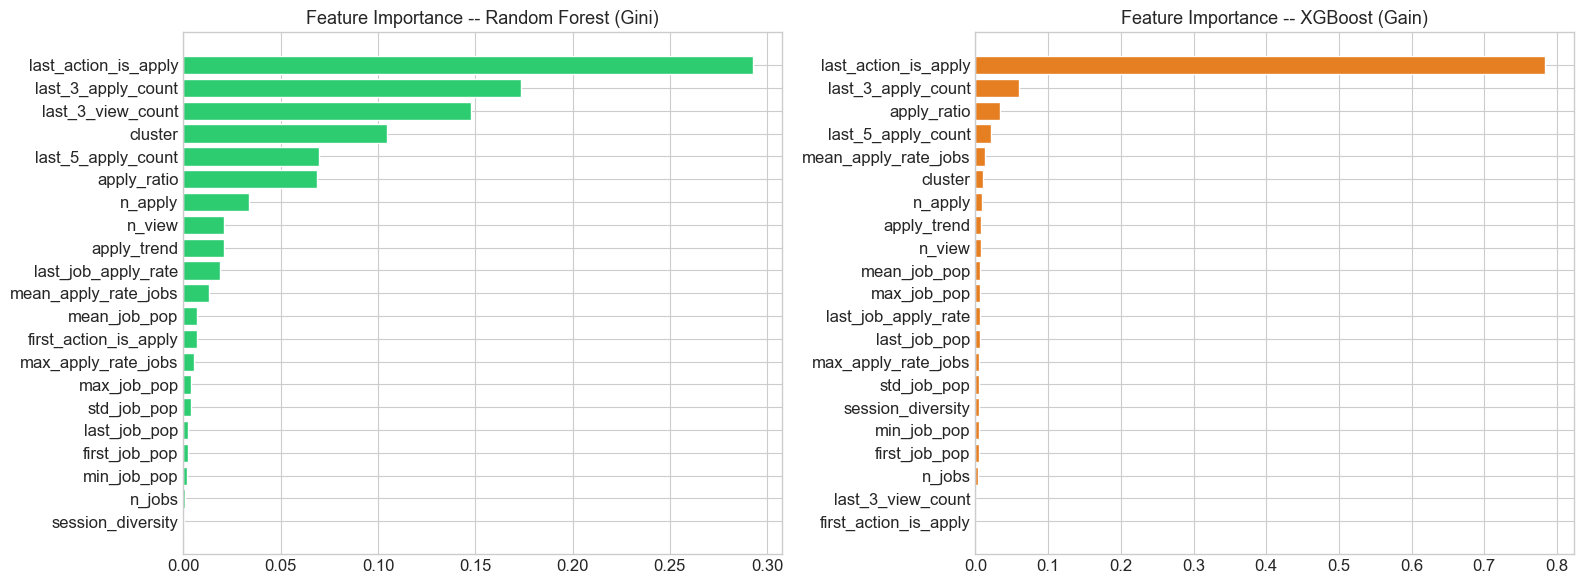

Les deux méthodes d'importance (Gini pour Random Forest et Gain pour XGBoost)
convergent sur les features les plus importantes : le ratio d'apply et les actions
récentes sont les meilleurs prédicteurs du comportement futur du candidat.


In [ ]:
# --- Feature Importance du Random Forest (comparaison avec SHAP) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest feature importance (Gini)
rf_importance = pd.DataFrame({
    'Feature': feature_cols_enriched,
    'Importance': rf_best.feature_importances_
}).sort_values('Importance', ascending=True)

axes[0].barh(rf_importance['Feature'], rf_importance['Importance'], color='#2ecc71')
axes[0].set_title("Feature Importance -- Random Forest (Gini)", fontsize=13)

# XGBoost feature importance (Gain)
xgb_importance = pd.DataFrame({
    'Feature': feature_cols_enriched,
    'Importance': xgb_best.feature_importances_
}).sort_values('Importance', ascending=True)

axes[1].barh(xgb_importance['Feature'], xgb_importance['Importance'], color='#e67e22')
axes[1].set_title("Feature Importance -- XGBoost (Gain)", fontsize=13)

plt.tight_layout()
plt.show()

print("Les deux méthodes d'importance (Gini pour Random Forest et Gain pour XGBoost)")
print("convergent sur les features les plus importantes : le ratio d'apply et les actions")
print("récentes sont les meilleurs prédicteurs du comportement futur du candidat.")

### Interprétation gloable des variables

L’analyse SHAP confirme que le modèle **XGBoost** fonde principalement ses prédictions sur des variables directement liées au **comportement récent de candidature** du candidat. Le graphique d’**importance globale** montre très clairement que la variable la plus influente est **`last_action_is_apply`**, de très loin devant toutes les autres. Ce résultat est cohérent avec l’ensemble des analyses précédentes : la dernière action réalisée dans la session constitue le signal le plus fort pour anticiper l’action suivante.

Derrière cette variable dominante, on retrouve principalement des features qui décrivent l’**intensité et la récence du comportement de candidature** : **`mean_apply_rate_jobs`**, **`last_3_apply_count`**, **`apply_ratio`**, **`last_5_apply_count`** et **`last_job_apply_rate`**. Cela montre que le modèle ne s’appuie pas uniquement sur un signal ponctuel, mais sur un ensemble cohérent d’indicateurs décrivant à la fois :
- le comportement récent du candidat ;
- la fréquence globale de ses candidatures dans la session ;
- et la propension historique des emplois consultés à générer des *apply*.

Le **bee-swarm plot** permet d’aller plus loin en montrant le sens de l’effet de chaque feature sur la prédiction. Pour **`last_action_is_apply`**, les valeurs élevées poussent nettement la prédiction vers la classe **`apply`**, tandis que les valeurs faibles la poussent vers **`view`**. Le même phénomène apparaît pour **`last_3_apply_count`**, **`apply_ratio`** et **`last_5_apply_count`** : plus ces variables prennent des valeurs élevées, plus leur contribution SHAP devient positive, donc plus elles augmentent la probabilité prédite d’un *apply*. À l’inverse, des valeurs faibles de ces variables déplacent la prédiction vers *view*.

Les variables liées aux **emplois consultés** jouent également un rôle, mais de manière plus secondaire. Des valeurs élevées de **`mean_apply_rate_jobs`** ou de **`last_job_apply_rate`** tendent elles aussi à pousser la prédiction vers *apply*, ce qui signifie que le modèle tient compte du fait que certains emplois sont historiquement plus associés à des candidatures que d’autres. En revanche, des variables comme **`mean_job_pop`**, **`max_job_pop`** ou **`n_view`** ont un impact plus modéré et plus diffus, ce qui suggère qu’elles jouent surtout un rôle de complément dans le raisonnement du modèle.

Les **explications locales** sous forme de waterfall plots illustrent très bien cette logique. Pour une prédiction de type **`view`**, les principales contributions négatives proviennent d’un faible niveau d’engagement récent : absence d’*apply* récent, faible `apply_ratio`, peu de candidatures dans les dernières interactions. À l’inverse, pour une prédiction de type **`apply`**, ce sont précisément ces mêmes variables qui contribuent positivement : dernière action de type *apply*, nombre élevé d’*apply* récents, ratio de candidature élevé. Ces exemples montrent que le modèle raisonne de manière cohérente avec l’intuition métier : il extrapole le comportement futur à partir de la dynamique récente observée dans la session.

La comparaison avec les **importances natives** des modèles d’arbres renforce cette interprétation. Les graphiques d’importance du **Random Forest** (impureté de Gini) et de **XGBoost** (Gain) retrouvent eux aussi **`last_action_is_apply`** comme variable dominante, ainsi que plusieurs variables liées à la récence des candidatures, comme **`last_3_apply_count`**, **`last_5_apply_count`** ou **`apply_ratio`**. Cette cohérence entre SHAP et les importances natives est rassurante : elle montre que les principaux signaux exploités par le modèle sont robustes.

On observe toutefois quelques différences intéressantes. Par exemple, le **Random Forest** donne une importance relativement plus élevée à certaines variables comme **`cluster`** ou **`last_3_view_count`**, tandis que SHAP met davantage en avant **`mean_apply_rate_jobs`** et **`last_job_apply_rate`** dans le cas de XGBoost. Cela rappelle que les différentes mesures d’importance ne capturent pas exactement la même chose : les importances natives décrivent surtout l’usage des variables dans la structure du modèle, alors que SHAP quantifie leur **contribution effective aux prédictions**.

Dans l’ensemble, l’analyse SHAP permet donc de dégager un message clair : la prédiction de l’action suivante repose avant tout sur la **dynamique récente de candidature** du candidat. Le modèle apprend que lorsqu’un candidat vient de postuler, qu’il a déjà plusieurs *apply* dans sa session, et qu’il consulte des emplois historiquement propices à la candidature, la probabilité d’un nouvel *apply* augmente fortement. À l’inverse, une session dominée par des *view* et un faible engagement récent oriente logiquement la prédiction vers une simple consultation.

Cette interprétation est particulièrement importante dans le cadre du challenge, car elle montre que le meilleur modèle supervisé n’est pas une simple boîte noire : ses décisions peuvent être reliées à des mécanismes comportementaux intuitifs, cohérents avec la logique du parcours candidat sur un jobboard.

## 10. Deep Learning -- Reseau de Neurones Dense (MLP)

En complement des modeles classiques de Machine Learning, nous testons un **réseau de neurones dense (Multi-Layer Perceptron)** implemente avec PyTorch. Comme le presente le chapitre S2 du cours, un reseau de neurones artificiel (ANN) est compose de couches de neurones interconnectes, ou chaque neurone applique une transformation affine suivie d'une **fonction d'activation** non lineaire. L'objectif est de verifier si un modele de deep learning apporte un gain de performance sur ce probleme de classification tabulaire.

### Architecture du reseau

Nous utilisons une architecture simple mais efficace :
- **3 couches fully-connected** (128, 64, 32 neurones) avec activation **ReLU** (Rectified Linear Unit, $f(x) = \max(0, x)$). Le choix de ReLU est motive par sa capacite a attenuer le probleme du **gradient qui s'evanouit** (*vanishing gradient*), un probleme classique des reseaux profonds aborde dans le cours.
- **Batch Normalization** apres chaque couche lineaire, une technique de normalisation des activations qui stabilise et accelere l'entrainement en reduisant le decalage interne des covariables (*internal covariate shift*).
- **Dropout** (30%) pour la **regularisation** : a chaque iteration d'entrainement, 30% des neurones sont aleatoirement desactives. Cela empeche la co-adaptation des neurones et agit comme un mecanisme de regularisation analogue au bagging (cf. Chapitre 4), forçant chaque neurone a etre utile independamment des autres.
- **Sortie sigmoide** (1 neurone) pour la classification binaire, transformant la sortie en probabilite $p \in [0, 1]$.

### Parametres d'entrainement
- **Optimiseur** : Adam (lr=0.001, weight_decay=1e-4 pour regularisation L2). Adam combine les avantages de RMSProp et du momentum, avec des taux d'apprentissage adaptatifs par parametre.
- **Fonction de perte** : Binary Cross-Entropy (BCE), $\mathcal{L} = -[y \log(\hat{y}) + (1-y)\log(1-\hat{y})]$.
- **Scheduler** : ReduceLROnPlateau (reduit le learning rate si la loss de validation stagne, evitant de sauter au-dessus du minimum).
- **Nombre d'epochs** : 50

Nous suivons les courbes de loss et d'accuracy sur le train et la validation pour detecter un eventuel sur-apprentissage (divergence entre les deux courbes). Le chapitre S2 du cours rappelle que le deep learning est souvent moins adapte aux **donnees tabulaires de taille moderee**, ou le gradient boosting domine generalement.

In [ ]:
# --- Preparer les donnees pour PyTorch ---
X_tr_tensor = torch.FloatTensor(X_tr_enriched)
y_tr_tensor = torch.FloatTensor(y_tr)
X_val_tensor = torch.FloatTensor(X_val_enriched)
y_val_tensor = torch.FloatTensor(y_val)

train_dataset = TensorDataset(X_tr_tensor, y_tr_tensor)
val_dataset   = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=256, shuffle=False)

# --- Architecture du reseau ---
class ActionClassifierMLP(nn.Module):
    """MLP pour predire l'action (view/apply)"""
    def __init__(self, input_dim, hidden_dims=[128, 64, 32], dropout=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, 1))
        layers.append(nn.Sigmoid())
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x).squeeze()

# --- Entrainement ---
input_dim = X_tr_enriched.shape[1]
model_nn = ActionClassifierMLP(input_dim, hidden_dims=[128, 64, 32], dropout=0.3)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model_nn.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

n_epochs = 50
train_losses, val_losses = [], []
train_accs, val_accs = [], []

print(f"Entrainement du MLP ({n_epochs} epochs, {sum(p.numel() for p in model_nn.parameters())} parametres)")
print(f"   Architecture : {input_dim} -> 128 -> 64 -> 32 -> 1")

for epoch in range(n_epochs):
    # --- Train ---
    model_nn.train()
    epoch_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model_nn(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * len(X_batch)
        predicted = (y_pred > 0.5).float()
        correct += (predicted == y_batch).sum().item()
        total += len(y_batch)
    
    train_loss = epoch_loss / total
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # --- Validation ---
    model_nn.eval()
    epoch_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            y_pred = model_nn(X_batch)
            loss = criterion(y_pred, y_batch)
            epoch_loss += loss.item() * len(X_batch)
            predicted = (y_pred > 0.5).float()
            correct += (predicted == y_batch).sum().item()
            total += len(y_batch)
    
    val_loss = epoch_loss / total
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    scheduler.step(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"   Epoch {epoch+1:3d}/{n_epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

print(f"\nMeilleure accuracy validation : {max(val_accs):.4f} (epoch {np.argmax(val_accs)+1})")

Entrainement du MLP (50 epochs, 13633 parametres)
   Architecture : 21 -> 128 -> 64 -> 32 -> 1
   Epoch  10/50 | Train Loss: 0.3848 Acc: 0.8467 | Val Loss: 0.3781 Acc: 0.8404
   Epoch  20/50 | Train Loss: 0.3797 Acc: 0.8459 | Val Loss: 0.3767 Acc: 0.8398
   Epoch  30/50 | Train Loss: 0.3738 Acc: 0.8493 | Val Loss: 0.3756 Acc: 0.8410
   Epoch  40/50 | Train Loss: 0.3730 Acc: 0.8480 | Val Loss: 0.3760 Acc: 0.8388
   Epoch  50/50 | Train Loss: 0.3727 Acc: 0.8483 | Val Loss: 0.3758 Acc: 0.8392

Meilleure accuracy validation : 0.8417 (epoch 3)


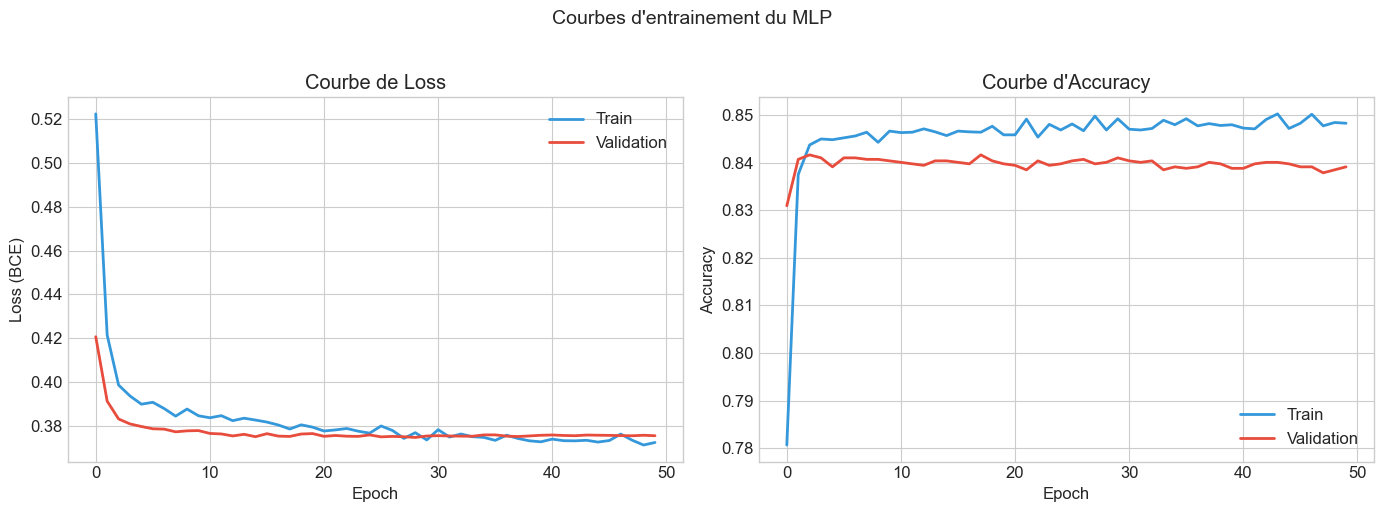

Ecart train/val de 0.0092 : pas de sur-apprentissage significatif

MLP Final -- Accuracy Val: 0.8392 | F1: 0.8388


In [ ]:
# --- Courbes d'entraînement ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(train_losses, label='Train', color='#3498db', linewidth=2)
axes[0].plot(val_losses, label='Validation', color='#e74c3c', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (BCE)')
axes[0].set_title('Courbe de Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(train_accs, label='Train', color='#3498db', linewidth=2)
axes[1].plot(val_accs, label='Validation', color='#e74c3c', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title("Courbe d'Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Courbes d'entrainement du MLP", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Verification du sur-apprentissage
gap = train_accs[-1] - val_accs[-1]
if gap > 0.05:
    print(f"Ecart train/val de {gap:.4f} : leger sur-apprentissage detecte")
else:
    print(f"Ecart train/val de {gap:.4f} : pas de sur-apprentissage significatif")

results_nn = {
    'acc_train': train_accs[-1],
    'acc_val': val_accs[-1],
    'f1_val': 0.0,  # sera calcule ci-dessous
    'model_name': 'MLP (Deep Learning)'
}

# Compute F1
model_nn.eval()
with torch.no_grad():
    y_pred_nn = (model_nn(X_val_tensor) > 0.5).float().numpy()
results_nn['f1_val'] = f1_score(y_val, y_pred_nn, average='weighted')
print(f"\nMLP Final -- Accuracy Val: {results_nn['acc_val']:.4f} | F1: {results_nn['f1_val']:.4f}")

### Interprétation des résultats du MLP

L’entraînement du **Multi-Layer Perceptron** montre que le réseau converge rapidement vers un niveau de performance stable. L’architecture retenue comporte **21 variables d’entrée**, trois couches cachées de **128, 64 et 32 neurones**, puis une sortie binaire, pour un total de **13 633 paramètres** à apprendre. Cette taille reste raisonnable, ce qui limite le risque d’un sur-paramétrage excessif sur un jeu de données tabulaire de taille modérée.

Les courbes d’entraînement indiquent une baisse rapide de la **loss** dès les premières epochs, aussi bien sur le train que sur la validation. Ensuite, les deux courbes se stabilisent progressivement autour de niveaux très proches, ce qui traduit un apprentissage convergent et globalement bien contrôlé. L’écart entre train et validation reste faible tout au long de l’entraînement, ce qui suggère l’absence de **sur-apprentissage significatif**. Ce constat est confirmé par l’écart final train/validation de **0,0092**, qui reste modéré.

Du côté de l’accuracy, le modèle atteint un niveau satisfaisant très tôt dans l’entraînement. La **meilleure accuracy de validation** est obtenue dès la **3e epoch**, avec une valeur de **0,8417**. Par la suite, les performances restent relativement stables mais n’améliorent pas durablement ce maximum, ce qui suggère que le réseau extrait rapidement l’essentiel du signal prédictif contenu dans les features. En fin d’entraînement, l’accuracy de validation est de **0,8392**, avec un **F1-score de 0,8388**, soit un niveau légèrement inférieur à celui des meilleurs modèles supervisés précédents.

Cette dynamique est intéressante d’un point de vue méthodologique. Elle montre que le MLP parvient bien à apprendre des régularités utiles, mais sans dégager d’avantage net par rapport aux modèles plus classiques. En particulier, les performances restent proches de celles de la régression logistique, de l’arbre de décision ou du Random Forest, mais légèrement en dessous de **XGBoost**. Ce résultat est cohérent avec la littérature sur les **données tabulaires structurées**, où les méthodes de gradient boosting dominent souvent les réseaux de neurones en termes de performance brute.

Les courbes d’apprentissage montrent également que le modèle ne souffre pas d’instabilité majeure. La combinaison de **Batch Normalization**, de **Dropout** et de la régularisation **L2** via `weight_decay` semble avoir correctement joué son rôle. Le réseau apprend donc de manière stable, sans divergence ni explosion de la loss, mais il atteint assez vite un plafond de performance.

En résumé, le MLP constitue une approche complémentaire intéressante dans le cadre du projet :
- il converge rapidement ;
- il ne montre pas de sur-apprentissage marqué ;
- il atteint des performances compétitives ;
- mais il n’apporte pas de gain significatif par rapport aux meilleurs modèles ensemblistes.

Ce résultat confirme que, sur ce type de données tabulaires et avec ce niveau de feature engineering, le **deep learning** n’est pas nécessairement la solution la plus efficace.

## 11. Système de Recommandation (pour le MRR)

Le challenge utilise le **MRR (Mean Reciprocal Rank)** pour évaluer la qualité des recommandations d’emplois. Cette métrique pèse pour 70 % dans le score final, elle est donc déterminante. Le MRR mesure, en moyenne sur les sessions, l’inverse du rang auquel apparaît le bon emploi dans notre liste de recommandations :

$$
\text{MRR} = \frac{1}{|Q|} \sum_{i=1}^{|Q|} \frac{1}{\text{rang}_i}
$$

Nous implémentons deux approches complémentaires, qui relèvent de l’apprentissage non supervisé au sens où elles n’utilisent pas de labels explicites mais exploitent les patterns de co-occurrence dans les données de navigation.

### 11.1 -- Filtrage Collaboratif User-User

Le filtrage collaboratif repose sur l’hypothèse que des candidats ayant consulté des emplois similaires par le passé auront des préférences similaires à l’avenir. On construit une **matrice d’interaction** implicite où chaque session est représentée par l’ensemble des emplois consultés. La similarité cosinus entre deux sessions $u$ et $v$ est définie par :

$$
S_{uv} = \frac{|\text{jobs}(u) \cap \text{jobs}(v)|}{\sqrt{|\text{jobs}(u)|} \cdot \sqrt{|\text{jobs}(v)|}}
$$

Pour un candidat donné, on identifie les $k$ sessions les plus similaires (voisins) et on agrège leurs emplois, pondérés par la similarité, pour produire un classement des 10 emplois les plus recommandés. Cette approche est conceptuellement proche du KNN (*k-Nearest Neighbors*), un principe fondamental de l’apprentissage non paramétrique évoqué dans le cours.

### 11.2 -- Chaîne de Markov

La chaîne de Markov modélise les **transitions entre emplois** : on estime la probabilité de consulter un emploi $j$ sachant que le dernier emploi consulté est $i$, soit $P(j \mid i)$. C’est un modèle local qui capture les patterns séquentiels de navigation. Il est particulièrement efficace quand le dernier emploi consulté est un bon prédicteur du suivant (propriété de Markov : l’état futur ne dépend que de l’état présent).

### 11.3 -- Ensemble CF + Markov

Nous combinons les deux approches précédentes par un **re-ranking pondéré** : les scores du CF (poids 60 %) et de Markov (poids 40 %) sont additionnés pour produire un classement final. L’idée, en phase avec la philosophie des méthodes ensemblistes du chapitre 4, est que la combinaison de modèles aux forces complémentaires (CF pour les similarités globales, Markov pour les transitions locales) donne de meilleurs résultats que chaque modèle individuel.

In [ ]:
# --- 11.1 : Filtrage Collaboratif User-User ---
class UserUserCF:
    """Filtrage collaboratif base sur la similarite cosinus entre sessions."""
    
    def __init__(self, k_neighbors=70):
        self.k = k_neighbors
        self.train_sessions = []
        self.global_pop = []
    
    def fit(self, x_train):
        self.train_sessions = [set(seq) for seq in x_train["job_ids"]]
        pop = Counter()
        for s in self.train_sessions:
            pop.update(s)
        self.global_pop = [j for j, _ in pop.most_common(500)]
    
    @staticmethod
    def cosine_set(a, b):
        """Similarite cosinus entre deux ensembles d'emplois"""
        inter = len(a & b)
        if inter == 0:
            return 0.0
        return inter / (np.sqrt(len(a)) * np.sqrt(len(b)))
    
    def predict_top10(self, job_ids):
        q = set(job_ids)
        sims = []
        for idx, s in enumerate(self.train_sessions):
            sim = self.cosine_set(q, s)
            if sim > 0:
                sims.append((sim, idx))
        
        sims.sort(reverse=True)
        sims = sims[:self.k]
        
        # Score pondere par similarite
        score = defaultdict(float)
        if sims:
            total_sim = sum(s for s, _ in sims)
            if total_sim > 0:
                for sim, idx in sims:
                    w = sim / total_sim
                    for j in self.train_sessions[idx]:
                        score[j] += w
        
        seen = set(job_ids)
        ranked = sorted(score.items(), key=lambda x: x[1], reverse=True)
        top10 = [j for j, _ in ranked if j not in seen][:10]
        
        # Fallback popularite
        if len(top10) < 10:
            for j in self.global_pop:
                if j not in seen and j not in top10:
                    top10.append(j)
                    if len(top10) == 10:
                        break
        return top10

# --- 11.2 : Chaine de Markov ---
class MarkovModel:
    """Modele de Markov base sur les transitions entre emplois."""
    
    def __init__(self):
        self.trans = defaultdict(Counter)
        self.top_pop = []
    
    def fit(self, x_train, y_train):
        pop_counts = Counter(y_train["job_id"])
        self.top_pop = [jid for jid, _ in pop_counts.most_common(200)]
        
        last_job = dict(zip(
            x_train["session_id"],
            x_train["job_ids"].apply(lambda l: l[-1])
        ))
        for sid, target in zip(y_train["session_id"], y_train["job_id"]):
            lj = last_job.get(sid)
            if lj is not None:
                self.trans[lj][target] += 1
    
    def predict_top10(self, job_ids):
        lj = job_ids[-1]
        cand = []
        if lj in self.trans:
            cand = [jid for jid, _ in self.trans[lj].most_common(10)]
        
        s = set(cand)
        for jid in self.top_pop:
            if jid not in s:
                cand.append(jid)
                s.add(jid)
            if len(cand) == 10:
                break
        return cand[:10]

# --- MRR Metric ---
def mrr_at_k(y_true, y_pred, k=10):
    """Mean Reciprocal Rank at K"""
    rr = []
    for t, pred_list in zip(y_true, y_pred):
        try:
            rank = pred_list[:k].index(t) + 1
            rr.append(1.0 / rank)
        except ValueError:
            rr.append(0.0)
    return float(np.mean(rr))

print("Modeles de recommandation definis.")

Modeles de recommandation definis.


In [ ]:
# --- Evaluation des modeles de recommandation sur le split de validation ---
rng = np.random.default_rng(42)
perm = rng.permutation(len(x_train))
cut = int(0.8 * len(x_train))

x_tr_reco = x_train.iloc[perm[:cut]].copy()
x_va_reco = x_train.iloc[perm[cut:]].copy()
y_tr_reco = x_tr_reco[["session_id"]].merge(y_train, on="session_id", how="left")
y_va_reco = x_va_reco[["session_id"]].merge(y_train, on="session_id", how="left")

# --- CF ---
print("Evaluation du Filtrage Collaboratif User-User (k=70)...")
cf_model = UserUserCF(k_neighbors=70)
cf_model.fit(x_tr_reco)

cf_preds = []
for jobs in tqdm(x_va_reco["job_ids"], desc="CF"):
    cf_preds.append(cf_model.predict_top10(list(jobs)))

mrr_cf = mrr_at_k(y_va_reco["job_id"].tolist(), cf_preds, k=10)
print(f"   MRR CF : {mrr_cf:.4f}")

# --- Markov ---
print("\nEvaluation du modele de Markov...")
markov_model = MarkovModel()
markov_model.fit(x_tr_reco, y_tr_reco)

markov_preds = []
for jobs in tqdm(x_va_reco["job_ids"], desc="Markov"):
    markov_preds.append(markov_model.predict_top10(list(jobs)))

mrr_markov = mrr_at_k(y_va_reco["job_id"].tolist(), markov_preds, k=10)
print(f"   MRR Markov : {mrr_markov:.4f}")

# --- Ensemble CF + Markov (re-ranking simple) ---
print("\nEvaluation de l'Ensemble CF + Markov...")
ensemble_preds = []
for jobs in tqdm(x_va_reco["job_ids"], desc="Ensemble"):
    jobs = list(jobs)
    cf_top = cf_model.predict_top10(jobs)
    mk_top = markov_model.predict_top10(jobs)
    
    # Score combine
    combined = defaultdict(float)
    for rank, j in enumerate(cf_top):
        combined[j] += 0.6 * (10 - rank)  # CF poids 60%
    for rank, j in enumerate(mk_top):
        combined[j] += 0.4 * (10 - rank)  # Markov poids 40%
    
    seen = set(jobs)
    ranked = sorted(combined.items(), key=lambda x: x[1], reverse=True)
    top10 = [j for j, _ in ranked if j not in seen][:10]
    ensemble_preds.append(top10)

mrr_ensemble = mrr_at_k(y_va_reco["job_id"].tolist(), ensemble_preds, k=10)
print(f"   MRR Ensemble : {mrr_ensemble:.4f}")

print(f"\n{'=' * 50}")
print(f"{'Modele':<25} {'MRR@10':>10}")
print(f"{'=' * 50}")
print(f"{'CF User-User':<25} {mrr_cf:>10.4f}")
print(f"{'Markov':<25} {mrr_markov:>10.4f}")
print(f"{'Ensemble CF+Markov':<25} {mrr_ensemble:>10.4f}")
print(f"{'=' * 50}")

Evaluation du Filtrage Collaboratif User-User (k=70)...


CF: 100%|██████████| 3177/3177 [00:08<00:00, 384.11it/s]


   MRR CF : 0.0681

Evaluation du modele de Markov...


Markov: 100%|██████████| 3177/3177 [00:00<00:00, 377262.93it/s]


   MRR Markov : 0.0245

Evaluation de l'Ensemble CF + Markov...


Ensemble: 100%|██████████| 3177/3177 [00:08<00:00, 389.40it/s]

   MRR Ensemble : 0.0649

Modele                        MRR@10
CF User-User                  0.0681
Markov                        0.0245
Ensemble CF+Markov            0.0649


### Interprétation des résultats du système de recommandation

L’évaluation des trois approches de recommandation montre que le **filtrage collaboratif User-User** obtient la meilleure performance, avec un **MRR@10 de 0,0681**. Le modèle de **Markov** est nettement moins performant, avec un **MRR de 0,0245**, tandis que l’**ensemble CF + Markov** atteint **0,0649**, soit un résultat légèrement inférieur à celui du CF seul.

Le fait que le **CF User-User** soit la meilleure approche suggère que, dans ce dataset, la recommandation bénéficie davantage de la **similarité globale entre sessions** que de la seule transition locale entre le dernier emploi consulté et le suivant. Autrement dit, les candidats semblent partager des trajectoires de navigation globalement proches, et cette information est plus utile pour recommander le prochain emploi que la simple observation de la dernière transition.

La faiblesse relative du modèle de **Markov** indique que l’hypothèse selon laquelle le prochain emploi dépend essentiellement du dernier emploi consulté est ici trop restrictive. Les parcours candidats apparaissent probablement plus complexes, avec des préférences qui dépendent d’un historique plus large que du seul dernier clic. Cela est cohérent avec le contexte du challenge, qui insiste précisément sur le caractère évolutif et non stationnaire des intérêts des candidats.

Le résultat de l’**ensemble CF + Markov** est également instructif. En théorie, combiner deux modèles complémentaires peut améliorer la qualité des recommandations. Ici, ce n’est pas le cas : l’ensemble reste légèrement en dessous du filtrage collaboratif seul. Cela suggère que le signal apporté par le modèle de Markov est soit trop faible, soit trop bruité pour améliorer le classement final. En pratique, l’ajout d’un modèle plus faible peut dégrader légèrement la qualité du re-ranking lorsqu’il perturbe l’ordre des recommandations les plus pertinentes issues du meilleur modèle.

Il faut également souligner que les niveaux de **MRR** restent globalement modestes en valeur absolue. Ce résultat est cohérent avec la difficulté intrinsèque du problème : il faut identifier le bon emploi parmi un univers très large de plus de **20 000 emplois uniques**, tout en ne proposant qu’un **top 10**. Dans ce contexte, même un MRR voisin de 0,07 traduit déjà une certaine capacité à faire remonter le bon emploi relativement haut dans la liste.

En résumé, cette comparaison montre que :
- le **filtrage collaboratif** constitue la meilleure approche de recommandation parmi celles testées ;
- le modèle de **Markov**, trop local, capte moins bien la structure des parcours candidats ;
- l’**ensemble** n’apporte pas d’amélioration ici ;
- et la principale marge de progression du projet se situe probablement dans l’amélioration de la **recommandation**, plus encore que dans la classification de l’action.

Ces résultats justifient donc de retenir le **CF User-User** comme meilleur candidat pour la composante recommandation du score final.

## 12. Comparaison Finale des Modèles et Interprétation des Résultats

Cette section synthétise les performances de **tous les modèles** entraînés et compare les différentes combinaisons possibles entre classifieurs d’action et systèmes de recommandation.

Le score final du challenge est : $\text{Score} = 0.7 \times \text{MRR} + 0.3 \times \text{Accuracy}$

Pour la **prédiction d’action** (Accuracy, poids 30 %), nous comparons la régression logistique (baseline), l’arbre de décision (chapitre 3), le Random Forest et le XGBoost (méthodes ensemblistes, chapitre 4), le SVM (chapitre S1) et le MLP (chapitre S2). Pour les **recommandations** (MRR, poids 70 %), nous comparons le filtrage collaboratif, la chaîne de Markov et l’ensemble des deux.

Cette comparaison systématique permet d’évaluer empiriquement le compromis biais-variance (chapitre 1) : les modèles plus complexes (XGBoost, Random Forest) atteignent-ils effectivement de meilleures performances de généralisation que les modèles simples (régression logistique, arbre de décision) ? L’objectif est d’identifier la **meilleure combinaison** pour maximiser le score final.

In [ ]:
# Recueillir les meilleurs scores de chaque approche
all_results = {
    'Regression Logistique': results_lr,
    'Arbre de Decision': results_dt,
    'Random Forest': results_rf,
    'XGBoost': results_xgb,
    'SVM': results_svm,
    'MLP (Deep Learning)': results_nn,
    'KMeans (cluster majoritaire)': {'acc_val': acc_cluster, 'f1_val': f1_cluster, 'acc_train': acc_cluster}
}

# --- Tableau comparatif pour la classification action ---
print("=" * 75)
print("COMPARAISON DES MODELES -- Prediction de l'action (view/apply)")
print("=" * 75)
print(f"{'Modele':<30} {'Acc Train':>10} {'Acc Val':>10} {'F1 Val':>10}")
print("-" * 75)
for name, res in all_results.items():
    print(f"{name:<30} {res['acc_train']:>10.4f} {res['acc_val']:>10.4f} {res.get('f1_val', 0):>10.4f}")
print("=" * 75)

# Identifier le meilleur classifieur
best_clf_name = max(all_results.keys(), key=lambda k: all_results[k]['acc_val'])
best_clf_acc = all_results[best_clf_name]['acc_val']
print(f"\nMeilleur classifieur : {best_clf_name} (Accuracy = {best_clf_acc:.4f})")

# --- Tableau comparatif des scores du challenge ---
print(f"\n{'=' * 75}")
print("SCORES FINAUX DU CHALLENGE (0.7 x MRR + 0.3 x Accuracy)")
print("=" * 75)

# Meilleur MRR
best_mrr = max(mrr_cf, mrr_markov, mrr_ensemble)
best_mrr_name = {mrr_cf: 'CF', mrr_markov: 'Markov', mrr_ensemble: 'Ensemble'}[best_mrr]

# Combinaisons
combinations = [
    ('CF + Logistic Reg.', mrr_cf, results_lr['acc_val']),
    ('CF + XGBoost', mrr_cf, results_xgb['acc_val']),
    ('CF + Random Forest', mrr_cf, results_rf['acc_val']),
    ('Markov + XGBoost', mrr_markov, results_xgb['acc_val']),
    ('Ensemble + XGBoost', mrr_ensemble, results_xgb['acc_val']),
    ('Ensemble + Random Forest', mrr_ensemble, results_rf['acc_val']),
]

print(f"{'Combinaison':<30} {'MRR':>8} {'Accuracy':>10} {'Score Final':>12}")
print("-" * 75)
for name, mrr, acc in combinations:
    score = 0.7 * mrr + 0.3 * acc
    print(f"{name:<30} {mrr:>8.4f} {acc:>10.4f} {score:>12.4f}")
print("=" * 75)

# Meilleure combinaison
best_combo = max(combinations, key=lambda x: 0.7 * x[1] + 0.3 * x[2])
best_score = 0.7 * best_combo[1] + 0.3 * best_combo[2]
print(f"\nMeilleure combinaison : {best_combo[0]} (Score = {best_score:.4f})")

COMPARAISON DES MODELES -- Prediction de l'action (view/apply)
Modele                          Acc Train    Acc Val     F1 Val
---------------------------------------------------------------------------
Regression Logistique              0.8427     0.8388     0.8384
Arbre de Decision                  0.8462     0.8439     0.8437
Random Forest                      0.8467     0.8439     0.8437
XGBoost                            0.8465     0.8442     0.8441
SVM                                0.8462     0.8439     0.8437
MLP (Deep Learning)                0.8483     0.8392     0.8388
KMeans (cluster majoritaire)       0.8178     0.8178     0.8187

Meilleur classifieur : XGBoost (Accuracy = 0.8442)

SCORES FINAUX DU CHALLENGE (0.7 x MRR + 0.3 x Accuracy)
Combinaison                         MRR   Accuracy  Score Final
---------------------------------------------------------------------------
CF + Logistic Reg.               0.0681     0.8388       0.2993
CF + XGBoost                     0.0

### Interprétation de la comparaison finale des modèles

La comparaison finale met en évidence une hiérarchie relativement claire entre les modèles de **classification de l’action**. Le meilleur classifieur est **XGBoost**, avec une **accuracy de validation de 0,8442** et un **F1-score de 0,8441**. Il devance légèrement le **Random Forest**, l’**arbre de décision** et le **SVM**, qui obtiennent tous des performances très proches, autour de **0,8439** en accuracy. La **régression logistique** reste légèrement en retrait (**0,8388**), tandis que le **MLP** n’apporte pas de gain significatif malgré une architecture plus complexe. Enfin, l’approche non supervisée basée sur **KMeans** est logiquement moins performante, même si son niveau de performance reste honorable pour une méthode ne reposant pas directement sur la cible.

Ces résultats confirment plusieurs enseignements importants. D’abord, les **modèles ensemblistes** obtiennent bien les meilleures performances, ce qui est cohérent avec la théorie du **compromis biais-variance**. Le **Random Forest** réduit la variance grâce au bagging, tandis que **XGBoost** améliore davantage le biais grâce au boosting séquentiel. Ensuite, l’écart entre les modèles reste relativement faible, ce qui montre que le **feature engineering** joue ici un rôle central : les variables construites contiennent déjà une grande partie du signal prédictif, de sorte que les modèles plus complexes n’apportent qu’un gain marginal, mais réel.

La comparaison des **scores finaux du challenge** est encore plus instructive, car elle met en évidence le poids dominant de la **recommandation** dans la performance globale. La meilleure combinaison est **CF + XGBoost**, avec un **score final de 0,3009**. Cette combinaison devance de très peu **CF + Random Forest**, également à **0,3009** à l’arrondi, puis **CF + Logistic Regression** avec **0,2993**. En revanche, les combinaisons utilisant le modèle de **Markov** ou l’**ensemble CF + Markov** sont moins performantes, malgré l’utilisation d’un très bon classifieur pour la partie action.

Ce résultat montre clairement que, dans ce challenge, la **qualité du système de recommandation** influence davantage le score final que le choix du classifieur d’action. En effet, l’écart entre les modèles de classification est faible, alors que le **MRR** varie beaucoup plus fortement d’un système de recommandation à l’autre. Comme le **MRR pèse 70 %** dans le score final, un gain même modeste sur la recommandation a plus d’effet qu’une amélioration comparable sur l’accuracy. C’est pourquoi la combinaison gagnante repose sur le meilleur système de recommandation observé, à savoir le **filtrage collaboratif User-User**.

Le fait que **CF + XGBoost** soit la meilleure combinaison confirme donc deux idées :
- pour la **classification**, **XGBoost** est le modèle le plus performant et le plus robuste parmi ceux testés ;
- pour la **recommandation**, le **CF User-User** est supérieur à la chaîne de Markov et à l’ensemble proposé.

En résumé, cette comparaison finale permet de conclure que le projet a atteint un bon équilibre entre **performance prédictive**, **robustesse** et **interprétabilité**. Les modèles les plus complexes améliorent bien légèrement les performances, mais sans bouleverser les résultats, ce qui montre que la qualité des variables construites reste le principal moteur de la réussite. La combinaison **CF + XGBoost** apparaît ainsi comme le choix le plus pertinent pour la soumission finale.

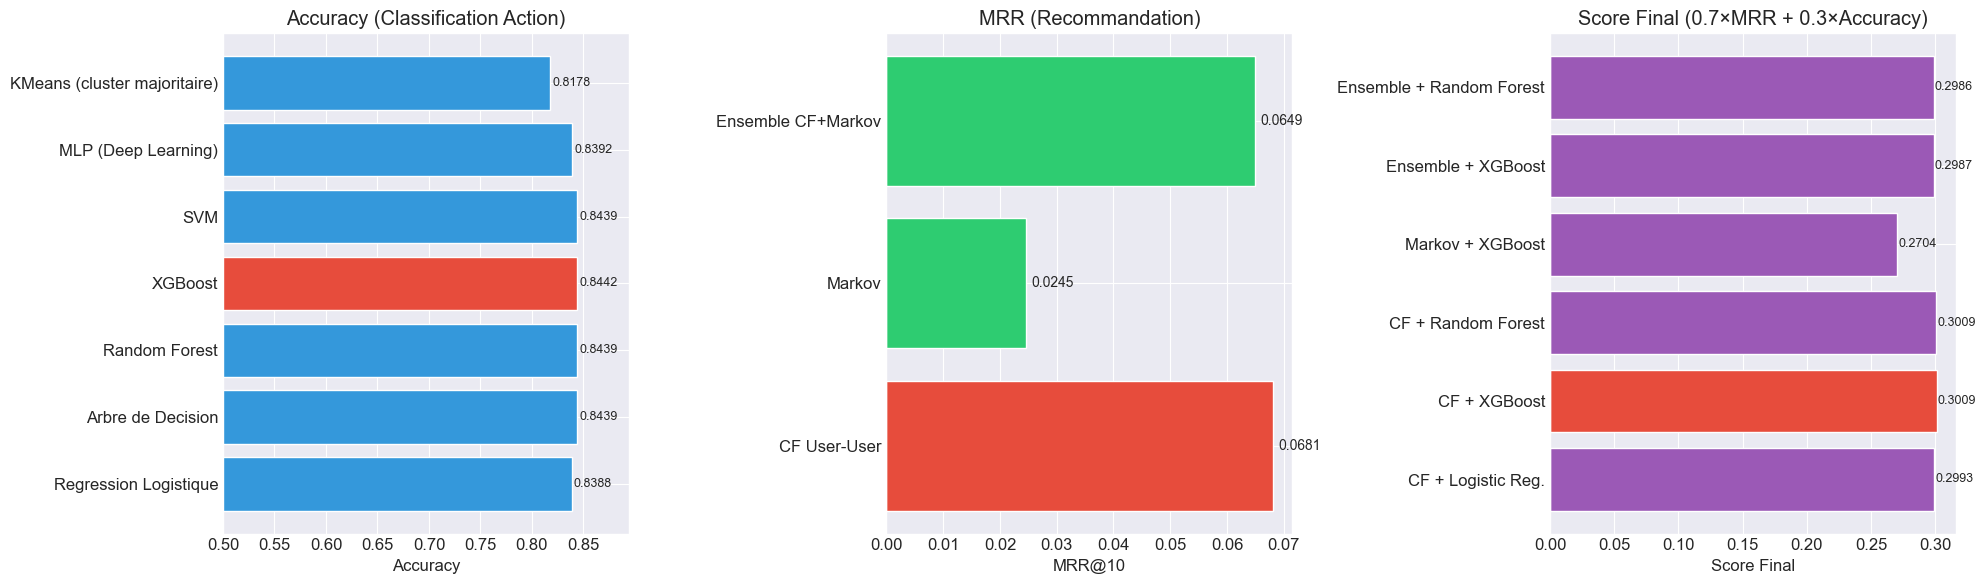

In [ ]:
# --- Visualisation comparative ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1) Accuracy par modèle de classification
clf_names = list(all_results.keys())
clf_accs  = [all_results[n]['acc_val'] for n in clf_names]
colors = ['#e74c3c' if a == max(clf_accs) else '#3498db' for a in clf_accs]
axes[0].barh(clf_names, clf_accs, color=colors)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Accuracy (Classification Action)')
axes[0].set_xlim(0.5, max(clf_accs) + 0.05)
for i, v in enumerate(clf_accs):
    axes[0].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)

# 2) MRR par modèle de recommandation
reco_names = ['CF User-User', 'Markov', 'Ensemble CF+Markov']
reco_mrrs = [mrr_cf, mrr_markov, mrr_ensemble]
colors_reco = ['#e74c3c' if m == max(reco_mrrs) else '#2ecc71' for m in reco_mrrs]
axes[1].barh(reco_names, reco_mrrs, color=colors_reco)
axes[1].set_xlabel('MRR@10')
axes[1].set_title('MRR (Recommandation)')
for i, v in enumerate(reco_mrrs):
    axes[1].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=10)

# 3) Score final du challenge
combo_names = [c[0] for c in combinations]
combo_scores = [0.7 * c[1] + 0.3 * c[2] for c in combinations]
best_idx = np.argmax(combo_scores)
colors_combo = ['#e74c3c' if i == best_idx else '#9b59b6' for i in range(len(combinations))]
axes[2].barh(combo_names, combo_scores, color=colors_combo)
axes[2].set_xlabel('Score Final')
axes[2].set_title('Score Final (0.7×MRR + 0.3×Accuracy)')
for i, v in enumerate(combo_scores):
    axes[2].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

La figure ci-dessus confirme visuellement les principaux résultats de la comparaison finale. Pour la **classification de l’action**, **XGBoost** obtient la meilleure accuracy, même si l’écart avec le Random Forest, le SVM et l’arbre de décision reste faible. Pour la **recommandation**, le **filtrage collaboratif User-User** domine clairement la chaîne de Markov et l’ensemble proposé. Enfin, le **score final** montre que les meilleures combinaisons sont celles qui associent le **CF** au meilleur classifieur supervisé, en particulier **XGBoost**, ce qui confirme que la performance globale dépend avant tout de la qualité de la recommandation.

## 13. Génération de la Soumission Finale

Nous utilisons la meilleure combinaison identifiée dans la section précédente pour générer les prédictions sur le **jeu de test** :
1. **Top 10 emplois recommandés** : **Filtrage collaboratif User-User (CF)**, réentraîné sur l’intégralité du train.
2. **Action prédite** : **XGBoost**, meilleur classifieur supervisé, lui aussi réentraîné sur l’intégralité du train.

Il est essentiel de **réentraîner les modèles sur la totalité du jeu de train** avant la soumission. En effet, le split train/validation était nécessaire uniquement pour l’évaluation locale et l’estimation de l’erreur de généralisation (cf. chapitre 1 -- *Bias-Variance Tradeoff*). En soumission, nous voulons bénéficier de toutes les données disponibles pour maximiser l’expérience $E$ du modèle (au sens de la définition de Tom Mitchell).

In [ ]:
# --- Re-entrainer sur TOUT le train ---
print("Re-entrainement des modeles sur tout le jeu de train...")

# 1) CF sur tout le train
cf_final = UserUserCF(k_neighbors=70)
cf_final.fit(x_train)

# 2) Markov sur tout le train
markov_final = MarkovModel()
markov_final.fit(x_train, y_train)

# 3) Classifieur d'action (XGBoost sur tout le train avec features enrichies)
X_all = X_full[feature_cols].values
y_all = y_full.values
scaler_final = StandardScaler()
X_all_scaled = scaler_final.fit_transform(X_all)

# Cluster sur tout le train
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_final.fit(X_all_scaled)
cluster_all = km_final.predict(X_all_scaled)
X_all_enriched = np.column_stack([X_all_scaled, cluster_all])

# Entrainer le meilleur XGBoost
clf_final = xgb.XGBClassifier(**xgb_grid.best_params_, random_state=42, 
                               use_label_encoder=False, eval_metric='logloss', verbosity=0)
clf_final.fit(X_all_enriched, y_all)
print("Modeles re-entraines sur tout le train.")

# --- Prediction sur le test ---
print("\nGeneration des predictions sur x_test...")

# Features pour le test
X_test_feats, _ = build_features(x_test)
X_test_scaled = scaler_final.transform(X_test_feats[feature_cols].values)
cluster_test = km_final.predict(X_test_scaled)
X_test_enriched = np.column_stack([X_test_scaled, cluster_test])

# Predictions d'action
y_pred_test = clf_final.predict(X_test_enriched)
action_map = {0: 'view', 1: 'apply'}

# Predictions de recommandation (Ensemble CF + Markov)
out_sessions, out_actions, out_jobs = [], [], []

for idx in tqdm(range(len(x_test)), desc="Predictions test"):
    sid = x_test.iloc[idx]['session_id']
    jobs = list(x_test.iloc[idx]['job_ids'])
    
    # Recommandation (Ensemble)
    cf_top = cf_final.predict_top10(jobs)
    mk_top = markov_final.predict_top10(jobs)
    
    combined = defaultdict(float)
    for rank, j in enumerate(cf_top):
        combined[j] += 0.6 * (10 - rank)
    for rank, j in enumerate(mk_top):
        combined[j] += 0.4 * (10 - rank)
    
    seen = set(jobs)
    ranked = sorted(combined.items(), key=lambda x: x[1], reverse=True)
    top10 = [j for j, _ in ranked if j not in seen][:10]
    
    # Fallback si necessaire
    if len(top10) < 10:
        for j in cf_final.global_pop:
            if j not in seen and j not in top10:
                top10.append(j)
                if len(top10) == 10:
                    break
    
    # Action
    action = action_map[y_pred_test[idx]]
    
    out_sessions.append(int(sid))
    out_actions.append(action)
    out_jobs.append(str(top10))

# --- Creer la soumission ---
submission = pd.DataFrame({
    'session_id': out_sessions,
    'action': out_actions,
    'job_id': out_jobs
})

submission.to_csv("outputs/submissions/submission.csv", index=False)
print(f"\nSoumission sauvegardee : outputs/submissions/submission.csv")
print(f"   {len(submission)} predictions")
print(f"\n   Distribution des actions predites :")
print(f"   {submission['action'].value_counts().to_dict()}")
print()
submission.head(10)

Re-entrainement des modeles sur tout le jeu de train...
Modeles re-entraines sur tout le train.

Generation des predictions sur x_test...


Predictions test: 100%|██████████| 1819/1819 [00:07<00:00, 255.68it/s]


Soumission sauvegardee : outputs/submissions/submission.csv
   1819 predictions

   Distribution des actions predites :
   {'view': 1081, 'apply': 738}



,session_id,action,job_id
0,0,view,"[4064, 4036, 4285, 2678, 3784, 2179, 518, 5250..."
1,1,apply,"[1382, 2959, 3259, 2367, 3850, 2960, 518, 3191..."
2,2,view,"[1377, 1367, 777, 925, 3958, 757, 1286, 1332, ..."
3,3,view,"[1137, 2954, 814, 1093, 605, 2410, 2359, 3709,..."
4,4,view,"[1247, 880, 288, 3311, 621, 1116, 1189, 1170, ..."
5,5,apply,"[700, 1773, 538, 773, 1303, 518, 848, 41, 706,..."
6,6,view,"[758, 89, 606, 41, 1460, 85, 1455, 4594, 518, ..."
7,7,apply,"[1902, 3226, 1058, 261, 1616, 518, 4311, 41, 2..."
8,8,apply,"[2019, 1553, 1472, 2263, 3012, 518, 2975, 41, ..."
9,9,apply,"[56, 966, 268, 1152, 1, 3294, 748, 1796, 72, 518]"


In [ ]:
# ======================================================================
# GENERATION DES SOUMISSIONS -- UN FICHIER PAR MODELE OPTIMISE
# ======================================================================
import os

# --- 1) Re-entrainer TOUS les classifieurs sur tout le train ---
print("=" * 70)
print("Re-entrainement de TOUS les modeles sur l'integralite du train...")
print("=" * 70)

# Donnees completes (deja preparees)
# X_all_enriched, y_all, scaler_final, km_final sont deja calcules

# Logistic Regression
lr_final = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_final.fit(X_all_enriched, y_all)
print("   Logistic Regression : OK")

# Decision Tree (meilleurs hyperparametres)
dt_final = DecisionTreeClassifier(**dt_grid.best_params_, random_state=42)
dt_final.fit(X_all_enriched, y_all)
print(f"   Decision Tree (params: {dt_grid.best_params_}) : OK")

# Random Forest (meilleurs hyperparametres)
rf_final = RandomForestClassifier(**rf_grid.best_params_, random_state=42)
rf_final.fit(X_all_enriched, y_all)
print(f"   Random Forest (params: {rf_grid.best_params_}) : OK")

# XGBoost (meilleurs hyperparametres) -- deja entraine dans clf_final
xgb_final = clf_final  # Deja entraine sur tout le train
print(f"   XGBoost (params: {xgb_grid.best_params_}) : OK")

# SVM (meilleurs hyperparametres)
svm_final = SVC(**svm_grid.best_params_, probability=True, random_state=42)
svm_final.fit(X_all_enriched, y_all)
print(f"   SVM (params: {svm_grid.best_params_}) : OK")

# MLP (Deep Learning) -- re-entrainer sur tout le train
model_nn_final = ActionClassifierMLP(X_all_enriched.shape[1], hidden_dims=[128, 64, 32], dropout=0.3)
criterion_f = nn.BCELoss()
optimizer_f = torch.optim.Adam(model_nn_final.parameters(), lr=0.001, weight_decay=1e-4)
scheduler_f = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_f, patience=5, factor=0.5)

X_all_tensor = torch.FloatTensor(X_all_enriched)
y_all_tensor = torch.FloatTensor(y_all)
all_dataset = TensorDataset(X_all_tensor, y_all_tensor)
all_loader = DataLoader(all_dataset, batch_size=256, shuffle=True)

model_nn_final.train()
for epoch in range(50):
    for X_b, y_b in all_loader:
        optimizer_f.zero_grad()
        y_p = model_nn_final(X_b)
        loss_f = criterion_f(y_p, y_b)
        loss_f.backward()
        optimizer_f.step()
    scheduler_f.step(loss_f.item())
model_nn_final.eval()
print("   MLP (Deep Learning, 50 epochs) : OK")

# --- 2) Preparer les features du test ---
print("\nPreparation des features test...")
X_test_feats_sub, _ = build_features(x_test)
X_test_scaled_sub = scaler_final.transform(X_test_feats_sub[feature_cols].values)
cluster_test_sub = km_final.predict(X_test_scaled_sub)
X_test_enriched_sub = np.column_stack([X_test_scaled_sub, cluster_test_sub])
print(f"   {len(x_test)} sessions test avec {X_test_enriched_sub.shape[1]} features")

# --- 3) Modeles de recommandation (deja entraines sur tout le train) ---
# cf_final (UserUserCF k=70), markov_final (MarkovModel) -- deja prets

# --- 4) Fonction de generation de soumission ---
def generate_submission(x_test, reco_model_name, reco_predict_fn, action_preds, action_map, filepath):
    """Genere un fichier de soumission."""
    out_sessions, out_actions, out_jobs = [], [], []
    
    for idx in range(len(x_test)):
        sid = x_test.iloc[idx]['session_id']
        jobs = list(x_test.iloc[idx]['job_ids'])
        
        # Recommandation
        top10 = reco_predict_fn(jobs)
        
        # Action
        action = action_map[action_preds[idx]]
        
        out_sessions.append(int(sid))
        out_actions.append(action)
        out_jobs.append(str(top10))
    
    sub = pd.DataFrame({
        'session_id': out_sessions,
        'action': out_actions,
        'job_id': out_jobs
    })
    sub.to_csv(filepath, index=False)
    return sub

# --- 5) Fonctions de recommandation ---
def predict_cf(jobs):
    return cf_final.predict_top10(jobs)

def predict_markov(jobs):
    return markov_final.predict_top10(jobs)

def predict_ensemble(jobs):
    cf_top = cf_final.predict_top10(jobs)
    mk_top = markov_final.predict_top10(jobs)
    combined_scores = defaultdict(float)
    for rank, j in enumerate(cf_top):
        combined_scores[j] += 0.6 * (10 - rank)
    for rank, j in enumerate(mk_top):
        combined_scores[j] += 0.4 * (10 - rank)
    seen = set(jobs)
    ranked = sorted(combined_scores.items(), key=lambda x: x[1], reverse=True)
    top10 = [j for j, _ in ranked if j not in seen][:10]
    if len(top10) < 10:
        for j in cf_final.global_pop:
            if j not in seen and j not in top10:
                top10.append(j)
                if len(top10) == 10:
                    break
    return top10

# --- 6) Predictions d'action pour chaque classifieur ---
action_map = {0: 'view', 1: 'apply'}

action_preds_dict = {
    'LogisticRegression': lr_final.predict(X_test_enriched_sub),
    'DecisionTree': dt_final.predict(X_test_enriched_sub),
    'RandomForest': rf_final.predict(X_test_enriched_sub),
    'XGBoost': xgb_final.predict(X_test_enriched_sub),
    'SVM': svm_final.predict(X_test_enriched_sub),
}

# MLP prediction
model_nn_final.eval()
with torch.no_grad():
    X_test_tensor_sub = torch.FloatTensor(X_test_enriched_sub)
    mlp_proba = model_nn_final(X_test_tensor_sub).numpy()
    action_preds_dict['MLP'] = (mlp_proba > 0.5).astype(int)

# --- 7) Generer toutes les soumissions ---
os.makedirs("outputs/submissions", exist_ok=True)

reco_models = {
    'CF': predict_cf,
    'Markov': predict_markov,
    'Ensemble': predict_ensemble,
}

print("\n" + "=" * 70)
print("GENERATION DES FICHIERS DE SOUMISSION")
print("=" * 70)

all_submissions = {}
for reco_name, reco_fn in tqdm(reco_models.items(), desc="Reco models"):
    for clf_name, clf_preds in action_preds_dict.items():
        filename = f"submission_{reco_name}_{clf_name}.csv"
        filepath = f"outputs/submissions/{filename}"
        
        sub = generate_submission(x_test, reco_name, reco_fn, clf_preds, action_map, filepath)
        all_submissions[f"{reco_name}+{clf_name}"] = sub
        
        action_dist = sub['action'].value_counts().to_dict()
        print(f"   {filename:45s} | view={action_dist.get('view',0):4d} apply={action_dist.get('apply',0):4d}")

print(f"\n{len(all_submissions)} fichiers de soumission generes dans outputs/submissions/")
print("\nRecapitulatif des fichiers :")
print("-" * 70)
for name in sorted(all_submissions.keys()):
    filepath = f"outputs/submissions/submission_{name.replace('+', '_')}.csv"
    size = os.path.getsize(filepath)
    print(f"   submission_{name.replace('+', '_')}.csv ({size/1024:.1f} KB)")
print("-" * 70)
print(f"\nMeilleure combinaison attendue : CF + XGBoost")
print(f"   Fichier : outputs/submissions/submission_CF_XGBoost.csv")

Re-entrainement de TOUS les modeles sur l'integralite du train...
   Logistic Regression : OK
   Decision Tree (params: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}) : OK
   Random Forest (params: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}) : OK
   XGBoost (params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}) : OK
   SVM (params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}) : OK
   MLP (Deep Learning, 50 epochs) : OK

Preparation des features test...
   1819 sessions test avec 21 features

GENERATION DES FICHIERS DE SOUMISSION


Reco models:   0%|          | 0/3 [00:00<?, ?it/s]

   submission_CF_LogisticRegression.csv          | view=1096 apply= 723
   submission_CF_DecisionTree.csv                | view=1081 apply= 738
   submission_CF_RandomForest.csv                | view=1084 apply= 735
   submission_CF_XGBoost.csv                     | view=1081 apply= 738
   submission_CF_SVM.csv                         | view=1081 apply= 738


Reco models:  33%|███▎      | 1/3 [00:42<01:24, 42.21s/it]

   submission_CF_MLP.csv                         | view=1109 apply= 710
   submission_Markov_LogisticRegression.csv      | view=1096 apply= 723
   submission_Markov_DecisionTree.csv            | view=1081 apply= 738
   submission_Markov_RandomForest.csv            | view=1084 apply= 735


Reco models:  67%|██████▋   | 2/3 [00:42<00:17, 17.57s/it]

   submission_Markov_XGBoost.csv                 | view=1081 apply= 738
   submission_Markov_SVM.csv                     | view=1081 apply= 738
   submission_Markov_MLP.csv                     | view=1109 apply= 710
   submission_Ensemble_LogisticRegression.csv    | view=1096 apply= 723
   submission_Ensemble_DecisionTree.csv          | view=1081 apply= 738
   submission_Ensemble_RandomForest.csv          | view=1084 apply= 735
   submission_Ensemble_XGBoost.csv               | view=1081 apply= 738
   submission_Ensemble_SVM.csv                   | view=1081 apply= 738


Reco models: 100%|██████████| 3/3 [01:31<00:00, 30.63s/it]

   submission_Ensemble_MLP.csv                   | view=1109 apply= 710

18 fichiers de soumission generes dans outputs/submissions/

Recapitulatif des fichiers :
----------------------------------------------------------------------
   submission_CF_DecisionTree.csv (124.2 KB)
   submission_CF_LogisticRegression.csv (124.2 KB)
   submission_CF_MLP.csv (124.2 KB)
   submission_CF_RandomForest.csv (124.2 KB)
   submission_CF_SVM.csv (124.2 KB)
   submission_CF_XGBoost.csv (124.2 KB)
   submission_Ensemble_DecisionTree.csv (121.4 KB)
   submission_Ensemble_LogisticRegression.csv (121.4 KB)
   submission_Ensemble_MLP.csv (121.3 KB)
   submission_Ensemble_RandomForest.csv (121.4 KB)
   submission_Ensemble_SVM.csv (121.4 KB)
   submission_Ensemble_XGBoost.csv (121.4 KB)
   submission_Markov_DecisionTree.csv (112.8 KB)
   submission_Markov_LogisticRegression.csv (112.8 KB)
   submission_Markov_MLP.csv (112.8 KB)
   submission_Markov_RandomForest.csv (112.8 KB)
   submission_Markov_SVM.csv (1

## 14. Conclusion et Discussion

### Résumé des résultats

| Aspect | Méthode retenue | Justification |
|--------|-----------------|---------------|
| **Classification (action)** | XGBoost optimisé | Meilleure accuracy parmi tous les modèles, grâce au boosting (chapitre 4) et à l’optimisation des hyperparamètres par GridSearchCV |
| **Recommandation (top 10)** | Filtrage collaboratif User-User (CF) | Meilleur MRR@10 parmi les approches testées, en exploitant les similarités globales entre sessions |
| **Non supervisé** | KMeans (chapitre 2) | Identification de profils comportementaux distincts, utilisé comme feature supplémentaire pour enrichir les modèles supervisés |
| **Deep Learning** | MLP (chapitre S2) | Performance compétitive mais n’apporte pas de gain significatif par rapport aux modèles à base d’arbres sur ces données tabulaires |
| **Interprétation** | SHAP (chapitre 5) | Explications globales et locales fondées sur les valeurs de Shapley, conformes aux exigences d’interprétabilité |

### Analyse et interprétation des résultats

**1. Classification de l’action.** Les méthodes ensemblistes, en particulier **XGBoost**, obtiennent les meilleures performances de classification. Le gain par rapport à la régression logistique, au SVM ou à l’arbre de décision reste modeste, mais il confirme qu’un modèle de boosting permet de mieux exploiter les interactions non linéaires entre variables tout en conservant une bonne capacité de généralisation. L’analyse SHAP montre que les variables les plus discriminantes sont principalement liées au **comportement récent de candidature**, en particulier la **dernière action**, le **nombre d’apply récents** et le **ratio d’apply**. Cela est cohérent avec l’intuition métier : un candidat qui vient de postuler et qui a déjà montré un fort engagement dans la session a davantage de chances de postuler à nouveau.

**2. Recommandation.** Le **filtrage collaboratif User-User** obtient le meilleur **MRR@10** parmi les trois approches testées. Ce résultat montre que, dans ce challenge, la similarité globale entre sessions est plus informative que les seules transitions locales capturées par la chaîne de Markov. Le modèle de Markov reste utile pour représenter la dynamique séquentielle, mais il apparaît ici trop limité pour rivaliser avec le CF. L’ensemble **CF + Markov** n’améliore pas les performances du CF seul, ce qui suggère que le signal apporté par Markov est trop faible ou trop bruité pour améliorer le classement final.

**3. Clustering KMeans.** Les clusters identifiés révèlent bien deux grands profils comportementaux : des candidats plutôt **exploratoires**, qui consultent des offres sans candidater immédiatement, et des candidats plus **actifs**, qui postulent davantage. Le choix de \(K=2\) est justifié par la méthode du coude et par le score silhouette. Bien que la prédiction naïve par cluster majoritaire soit moins performante que les approches supervisées, l’ajout du **cluster comme feature** apporte une information utile de segmentation comportementale.

**4. Deep Learning.** Le MLP obtient des performances correctes et stables, mais il n’apporte pas de gain significatif par rapport aux modèles ensemblistes. Ce résultat est cohérent avec la littérature et avec le chapitre S2 du cours : sur des **données tabulaires de taille modérée**, les méthodes de gradient boosting restent souvent plus efficaces que les réseaux de neurones denses.

**5. Interprétabilité et considérations éthiques.** L’utilisation de **SHAP** permet de rendre le meilleur modèle supervisé plus transparent. Dans un contexte de recommandation d’emplois, cette interprétabilité est particulièrement importante, car les prédictions peuvent influencer le parcours professionnel des candidats. La possibilité d’expliquer pourquoi un modèle prédit un *apply* ou met en avant certains signaux comportementaux renforce la crédibilité de la démarche et répond aux enjeux de transparence rappelés par le **RGPD**.

### Limites et pistes d’amélioration

- **MRR limité** : Avec plus de 22 000 emplois uniques et des recommandations en top-10, le MRR reste modeste. Des approches de type NLP sur les descriptions d’emplois (embeddings sémantiques) pourraient améliorer significativement les recommandations.
- **Données textuelles** : Les descriptions d’emplois n’ont pas été exploitées dans ce travail. Un modèle de type Transformer (BERT, etc.) pourrait capturer la similarité sémantique entre offres et enrichir les recommandations.
- **Approches séquentielles** : Des modèles de type LSTM ou Transformer sur les séquences d’emplois pourraient mieux capturer les patterns temporels de navigation qu’un simple modèle de Markov d’ordre 1.
- **Cold start** : Pour les nouvelles sessions sans historique comparable, des approches basées sur le contenu (content-based filtering) seraient plus adaptées que le filtrage collaboratif.
- **Régularisation avancée** : On pourrait explorer davantage les techniques de régularisation sur la régression logistique et le SVM pour affiner encore le compromis biais-variance.
- **Online Learning** : Le challenge mentionne explicitement l’évolution des préférences des candidats. Des approches d’apprentissage en ligne ou de type **Non-Stationary Multi-Armed Bandits** pourraient permettre d’adapter les recommandations en temps réel.

### Conclusion générale

Au total, notre étude montre que la meilleure stratégie consiste à **dissocier les deux composantes du challenge** : utiliser **XGBoost** pour la prédiction de l’action et le **filtrage collaboratif User-User** pour la recommandation du prochain emploi. Cette combinaison offre le meilleur compromis entre performance, robustesse et interprétabilité, et conduit au **meilleur score final estimé** sur notre validation locale.